In [63]:
import numpy as np
import numba
from numba import njit, prange
import progressbar
import math
import cmath
from cmath import pi
from tkinter import W
import pandas as pd
import matplotlib as mp
import matplotlib.pyplot as plt
import time
import joblib
from joblib import Parallel, delayed
from tempfile import mkdtemp
from scipy import signal
import scipy
import csv
from operator import mod
from turtle import shape
from IPython.display import display, Math
from operator import mul
from functools import reduce
from scipy.optimize import fsolve
import sdeint
import multiprocessing
import os.path as path
from tqdm import tqdm
import warnings
import matplotlib.gridspec as gridspec
import os
from scipy.stats import ks_2samp
import pyperclip
warnings.filterwarnings("ignore", category=DeprecationWarning)

def MY_JUMPY_SDEINT(N,F,G,Ksi2,Lambda,dt,nsteps,x0, method="itoint"):
    sdeint_methods = {
        "itoint": sdeint.itoint,
        "stratint": sdeint.stratint,
        "itoEuler": sdeint.itoEuler,
        "stratHeun": sdeint.stratHeun,
        "itoSRI2": sdeint.itoSRI2,
        "stratSRS2": sdeint.stratSRS2,
        "stratKP2iS": sdeint.stratKP2iS
    }
    if method not in sdeint_methods:
        raise ValueError(f"Invalid method '{method}'. Choose from {list(sdeint_methods.keys())}.")
    sdeint_method = sdeint_methods[method]

    x=np.zeros((N,nsteps))
    x[:,0]=x0
    for i in range(1,nsteps):
        x[:,i]=sdeint_method(F, G, x[:,i-1], np.array([(i-1)*dt, i*dt]))[-1]
        rate = Lambda(x[:,i-1],(i-1)*dt)
        for n in range(N):  
            if np.random.rand() < rate[n] * dt:  
                J = Ksi2(x[:,i-1],(i-1)*dt) 
                for row in range(N):
                    x[row,i] += np.random.normal(0,np.sqrt(J[row, n]))  

    return x

@njit
def MY_JUMPY_SDEINT(N, F, G, Ksi2, Lambda, dt, nsteps, x0):
    x = np.zeros((N, nsteps))
    x[:, 0] = x0
    sqrt_dt = np.sqrt(dt)
    
    for i in range(nsteps - 1):
        t = i * dt
        # Wiener increment and its square minus dt
        dW = np.random.normal(0.0, sqrt_dt, N)
        dZ = 0.5 * (dW**2 - dt)        
        # First intermediate step (K1)
        k1 = x[:, i] + F(x[:, i], t) * dt + np.dot(G(x[:, i], t), dW)
        # Second intermediate step (K2)
        # F_k1 = F(k1, t + dt)
        # G_k1 = G(k1, t + dt)
        # Update: Runge-Kutta style (Milstein-like correction)
        x[:, i + 1] = x[:, i] + 0.5 * (F(x[:, i], t) + F(k1, t + dt)) * dt \
                        + np.dot(G(x[:, i], t), dW) \
                        + np.dot((G(k1, t + dt) - G(x[:, i], t)), dZ)
        # Jump part
        rate = Lambda(x[:, i], t)
        J = Ksi2(x[:, i], t)
        for n in range(N):
            if np.random.rand() < rate[n] * dt:
                jump_noise = np.random.normal(0.0, 1.0, N)
                for row in range(N):
                    x[row, i + 1] += np.sqrt(J[row, n]) * jump_noise[row]
                    
    return x

def caly(x,N):
    xshape=x.shape

    y=np.zeros((N,xshape[1])) 
    for i in range(N):
        y[i,:]=(np.roll(x[i,:],-1)-x[i,:])  
    x2=np.zeros((N,xshape[1]-1))  
    y2=np.zeros((N,xshape[1]-1))    
    for i in range(N):
        x2[i,:]=np.delete(x[i,:],-1)
        y2[i,:]=np.delete(y[i,:],-1) 
    return x2,y2   

def calpowercoef(N,M,mode):
    if mode=='lim':
        powercoef=np.zeros((1+sum(N**M for M in range(1,M+1)),N))
        counter=0
        for j in range(1,M+1):
            for k in range(1,N**j+1):
                counter+=1
                for l in range(1,j+1):
                    x=math.ceil(k/N**(j-l))
                    if (x==0): x=N
                    k=mod(k,N**(j-l))
                    powercoef[int(counter),x-1]+=1
        powercoef2,ind=np.unique(powercoef,axis=0,return_index=True)
        powercoef2=powercoef2[np.argsort(ind)]
    elif mode=='list':
        powercoef=np.zeros((sum(N**M for M in M),N))
        counter=0
        for j in M:
            for k in range(1,N**j+1):
                counter+=1
                for l in range(1,j+1):
                    x=math.ceil(k/N**(j-l))
                    if (x==0): x=N
                    k=mod(k,N**(j-l))
                    powercoef[int(counter)-1,x-1]+=1
        powercoef2,ind=np.unique(powercoef,axis=0,return_index=True)
        powercoef2=powercoef2[np.argsort(ind)]        
    else:
        raise ValueError("mode can only be 'lim' or 'list' ")
    return powercoef2

@njit()  # parallel=True
def calM2(x,N,powercoef):
    mdim=len(powercoef)
    M2=np.zeros((mdim,mdim))
    xshape=x.shape
    for i1 in range(mdim):
        for i2 in range(i1,mdim):
            a=np.ones(xshape[1])
            pc=powercoef[i1,:]+powercoef[i2,:]
            for i in range(N):
                a=a*x[i,:]**pc[i]
            M2[i1,i2]=np.mean(a)
            M2[i2,i1]=M2[i1,i2]             
    return M2

@njit()  # parallel=True
def calM1(l,ilist,x,y,N,powercoef):
    mdim=len(powercoef)
    M1=np.zeros(mdim)
    xshape=x.shape
    for i1 in range(mdim):
        a=np.ones(xshape[1])
        for i in range(l):
            a=a*y[ilist[i],:] 
        for i in range(N):
            a=a*x[i,:]**powercoef[i1,i]
        M1[i1]=np.mean(a)        
    return M1

def calDlcoef(l,x,y,dt,N,M,mode):
    powercoef=calpowercoef(N,M,mode)

    C_keys = []
    for i in range(len(powercoef)):
        temp = []
        for j in range(N):
            if powercoef[i, j] != 0:
                temp.append(f"x{j+1}^{int(powercoef[i, j])}")
        C_keys.append("*".join(temp))  # Join terms with '*'
    if C_keys[0] == '':
        C_keys[0] = '1'


    Dcoeffs=pd.DataFrame()
    M2=calM2(x,N,powercoef)


    if l==1:
        for i in range(N):   
            ilist=np.array([i])
            M1=calM1(1,ilist,x,y,N,powercoef)
            Dcoef=np.linalg.solve(M2,M1)/dt
            Dcoeffs[f"M\u2081{i+1}"]=Dcoef 

    elif l==2:
        for i in range(N):
            for j in range(i,N):   
                ilist=np.array([i,j])
                M1=calM1(2,ilist,x,y,N,powercoef)
                Dcoef=np.linalg.solve(M2,M1)/dt
                Dcoeffs[f"M\u2082{i+1}{j+1}"]=Dcoef  

    elif l==4:
        for i in range(N):
            for j in range(i,N):   
                ilist=np.array([i,i,j,j])
                M1=calM1(4,ilist,x,y,N,powercoef)
                Dcoef=np.linalg.solve(M2,M1)/dt
                Dcoeffs[f"M\u2084{i+1}{i+1}{j+1}{j+1}"]=Dcoef 

    elif l==6:
        for i in range(N):
            for j in range(i,N): 
                for k in range(j,N):  
                    ilist=np.array([i,i,j,j,k,k])
                    M1=calM1(6,ilist,x,y,N,powercoef)
                    Dcoef=np.linalg.solve(M2,M1)/dt
                    Dcoeffs[f"M\u2086{i+1}{i+1}{j+1}{j+1}{k+1}{k+1}"]=Dcoef 


    elif l==246:
        for i in range(N):
            for j in range(i,N):   
                ilist=np.array([i,j])
                M1=calM1(2,ilist,x,y,N,powercoef)
                Dcoef=np.linalg.solve(M2,M1)/dt
                Dcoeffs[f"M\u2082{i+1}{j+1}"]=Dcoef 
        for i in range(N):
            for j in range(i,N):   
                ilist=np.array([i,i,j,j])
                M1=calM1(4,ilist,x,y,N,powercoef)
                Dcoef=np.linalg.solve(M2,M1)/dt
                Dcoeffs[f"M\u2084{i+1}{i+1}{j+1}{j+1}"]=Dcoef 
        for i in range(N):
            for j in range(i,N): 
                for k in range(j,N):  
                    ilist=np.array([i,i,j,j,k,k])
                    M1=calM1(6,ilist,x,y,N,powercoef)
                    Dcoef=np.linalg.solve(M2,M1)/dt
                    Dcoeffs[f"M\u2086{i+1}{i+1}{j+1}{j+1}{k+1}{k+1}"]=Dcoef         

    elif l==46:
        for i in range(N):
            for j in range(i,N):   
                ilist=np.array([i,i,j,j])
                M1=calM1(4,ilist,x,y,N,powercoef)
                Dcoef=np.linalg.solve(M2,M1)/dt
                Dcoeffs[f"M\u2084{i+1}{i+1}{j+1}{j+1}"]=Dcoef 
        for i in range(N):
            for j in range(i,N): 
                for k in range(j,N):  
                    ilist=np.array([i,i,j,j,k,k])
                    M1=calM1(6,ilist,x,y,N,powercoef)
                    Dcoef=np.linalg.solve(M2,M1)/dt
                    Dcoeffs[f"M\u2086{i+1}{i+1}{j+1}{j+1}{k+1}{k+1}"]=Dcoef         






    Dcoeffs.index = C_keys
    col=Dcoeffs.columns
    ind=Dcoeffs.index
    return Dcoeffs,ind,col

def calallDcoef(x,y,dt,N,M,mode):
    powercoef=calpowercoef(N,M,mode)

    C_keys=[]
    for i in range(len(powercoef)):
        temp=""
        for j in range(N):
            if powercoef[i,j]!=0:
                temp=temp+f"x{j+1}^{int(powercoef[i,j])}"
        C_keys.append(temp)
    if C_keys[0] == '':
            C_keys[0] ='1'

    Dcoeffs=pd.DataFrame()
    M2=calM2(x,N,powercoef)



    for i in range(N):    
        ilist=np.array([i])
        M1=calM1(1,ilist,x,y,N,powercoef)
        Dcoef=np.linalg.solve(M2,M1)/dt
        Dcoeffs[f"M\u2081{i+1}"]=Dcoef 
    for i in range(N): 
        for j in range(i,N):   
            ilist=np.array([i,j])
            M1=calM1(2,ilist,x,y,N,powercoef)
            Dcoef=np.linalg.solve(M2,M1)/dt
            Dcoeffs[f"M\u2082{i+1}{j+1}"]=Dcoef 
    for i in range(N): 
        for j in range(i,N):   
            ilist=np.array([i,i,j,j])
            M1=calM1(4,ilist,x,y,N,powercoef)
            Dcoef=np.linalg.solve(M2,M1)/dt
            Dcoeffs[f"M\u2084{i+1}{i+1}{j+1}{j+1}"]=Dcoef 
    for i in range(N): 
        for j in range(i,N): 
            for k in range(j,N):  
                ilist=np.array([i,i,j,j,k,k])
                M1=calM1(6,ilist,x,y,N,powercoef)
                Dcoef=np.linalg.solve(M2,M1)/dt
                Dcoeffs[f"M\u2086{i+1}{i+1}{j+1}{j+1}{k+1}{k+1}"]=Dcoef 
    Dcoeffs.index = C_keys
    col=Dcoeffs.columns
    ind=Dcoeffs.index
    return Dcoeffs,ind,col

#####################################################################################################################################################

def PlotTS(N, data, dt, PT):
    plt.figure(figsize=(25,5 ))
    for i in range(N):
        plt.plot(np.linspace(0,PT,len(data[i,:int(PT/dt)])), data[i,:int(PT/dt)])
    plt.xlim(-0.02*PT,PT+0.02*PT)
    plt.ylabel(r'$x$') 
    plt.xlabel('Time') 
    plt.show()

def load_multiple_files(base_dir, exn, data_lengths, M_values):
    data_dict = {}
    nof=0
    for data_length in data_lengths:
        for M in M_values:
            filename = f"{exn}-T={data_length}-M{M}-data.csv"
            file_path = os.path.join(base_dir, "data", filename)
            try:
                data = pd.read_csv(file_path,index_col=0)
                data_dict[(data_length, M)] = data
                #print(f"Loaded {filename}")
                nof+=1
            except FileNotFoundError:
                print(f"File {filename} not found. Skipping.")
    print(nof, "Files read")
    return data_dict

def GetAdressList(N):
    adress_list = np.zeros((int(2*(N+N*(N+1)+N*(N+1)*(N+2)/6)), 2), dtype=int)
    adress_list2 = np.zeros((int((N+N*(N+1)+N*(N+1)*(N+2)/6)), 2), dtype=int)
    
    ii=0
    start = 0
    end = 2*N
    for i in range(int(start),int(end), 2):
        adress_list[i,0] = 1
        adress_list[i,1] = ii
        adress_list[i+1,0] = 1
        adress_list[i+1,1] = ii+2*N
        ii+=1
    ii=0
    start = 2*N
    end = 2*N + N*(N+1)
    for i in range(int(start),int(end), 2):
        adress_list[i,0] = 2
        adress_list[i,1] = ii
        adress_list[i+1,0] = 2
        adress_list[i+1,1] = ii+(N*(N+1))
        ii+=1
    ii=0
    start = 2*N + N*(N+1)
    end = 2*N + N*(N+1) + N*(N+1)
    for i in range(int(start),int(end), 2):
        adress_list[i,0] = 4
        adress_list[i,1] = ii
        adress_list[i+1,0] = 4
        adress_list[i+1,1] = ii+(N*(N+1))
        ii+=1
    ii=0
    start = 2*N + N*(N+1) + N*(N+1)
    end = 2*N + N*(N+1) + N*(N+1) + N*(N+1)*(N+2)/3
    for i in range(int(start),int(end), 2):
        adress_list[i,0] = 6
        adress_list[i,1] = ii
        adress_list[i+1,0] = 6
        adress_list[i+1,1] = ii+(N*(N+1)*(N+2)/3)
        ii+=1
    for i in range(0, len(adress_list), 2):
        adress_list2[int(i/2),0] = adress_list[i,0]
        adress_list2[int(i/2),1] = adress_list[i,1]
    return adress_list, adress_list2

def Getcol_numbers(N):
    col_numbers = np.zeros ()

def GetLables(N):
    labels = ['\\alpha']  # Start with alpha
    # Add phi labels
    labels.extend([f'\\phi_{i+1}' for i in range(N)])
    # Add theta labels
    labels.extend([f'\\theta_{{{i+1}{j+1}}}' for i in range(N) for j in range(i, N)])
    # Add gamma labels
    labels.extend([f'\\gamma_{{{"".join(map(str, [i+1, j+1, k+1]))}}}' for i in range(N) for j in range(i, N) for k in range(j, N)])
    return labels

#####################################################################################################################################################

def CreatPlots(histdata, chosentimesindex, binrnge, nbins, chosendimension, timestep_labels, Examplename):
    powers = [10, 8, 6, 4, 2, 0]
    labels = [r"$x^{{{}}} p(x)$".format(p) for p in powers]
    # labels = [f"x^{p} p(x)" for p in powers]

    xaxis = np.linspace(binrnge[0],binrnge[1],nbins)

    hist_mean = np.mean(histdata, axis=1)  
    hist_std = np.std(histdata, axis=1)/np.sqrt(30) 
       
    fig = plt.figure(figsize=(15, 25)) 
    gs = gridspec.GridSpec(2, 2, hspace=0.5, wspace=0.1)  
    fig.suptitle(Examplename+"   "+chosendimension, fontsize=20)
    gs_11 = gridspec.GridSpecFromSubplotSpec(6, 1, subplot_spec=gs[0,0],  hspace=0.1, wspace=0.1)              #height_ratios=[1], width_ratios=[3.5,1],
    gs_12 = gridspec.GridSpecFromSubplotSpec(6, 1, subplot_spec=gs[0,1],  hspace=0.1, wspace=0.1) 
    gs_21 = gridspec.GridSpecFromSubplotSpec(6, 1, subplot_spec=gs[1,0],  hspace=0.1, wspace=0.1) 
    gs_22 = gridspec.GridSpecFromSubplotSpec(6, 1, subplot_spec=gs[1,1],  hspace=0.1, wspace=0.1)   
    gs_list  = [gs_11, gs_12, gs_21, gs_22]

    axs_groups = []


    # Loop through each panel
    for idx, gs_sub in enumerate(gs_list):
        axs = [] 
        for row_idx, power in enumerate(powers):
            ax = fig.add_subplot(gs_sub[row_idx, 0])
            y = (xaxis ** power) * hist_mean[idx]
            yerr = (xaxis ** power) * hist_std[idx]
            ax.errorbar(xaxis, y, yerr=yerr, fmt='o', markersize=3, color='black', ecolor='red', capsize=2)
            # ax.set_ylim((-0.01*max(y), 1.05*max(y)))
            ax.set_ylabel(labels[row_idx], fontsize=10)

            if row_idx != 5:
                ax.set_xticklabels([])  # Hide x-axis labels except bottom row
            if row_idx == 0:
                ax.set_title( f"({timestep_labels[idx]})", fontsize=12)


            axs.append(ax)
        axs_groups.append(axs)
    for axs in axs_groups:
        fig.align_ylabels(axs)
        
    plt.savefig("D:/U/M/M-P/codes and res/Ultimate_Examples/Plots/"+Examplename+"_"+chosendimension+"_StopCon.jpeg", dpi=300)
    # plt.show()
    plt.close()

def PlotMoments(path1, exn, Examplename, chosentimes, dx_init, dx_new):
    # Load histograms
    histlist = []
    nbins_list = []
    for i in range(len(chosentimes)):
        hist = np.load(path1 + exn + "/data/" + exn + f"_AllHistarray_{chosentimes[i]}.npy")
        histlist.append(hist)
        nbins_list.append(hist.shape[2])
    # Find max nbins
    max_nbins = max(nbins_list)
    print("Maximum nbins found:", max_nbins)
    # Pad histograms to max_nbins
    padded_histlist = []
    for hist in histlist:
        nbins = hist.shape[2]
        if nbins < max_nbins:
            pad_width = (max_nbins - nbins) // 2
            hist_padded = np.pad(hist, ((0, 0), (0, 0), (pad_width, pad_width)), mode='constant')
        else:
            hist_padded = hist
        padded_histlist.append(hist_padded)
    # Convert to array (optional)
    padded_histarray = np.array(padded_histlist)
    print("Shape after padding:", padded_histarray.shape)

    # Calculate new number of bins
    new_nbins = int(max_nbins * dx_init / dx_new)
    print("New nbins after rebinning:", new_nbins)
    # Define rebinning function
    def rebin_histogram(hist, new_nbins):
        old_nbins = hist.shape[2]
        factor = old_nbins // new_nbins
        if old_nbins % new_nbins != 0:
            # Trim the extra bins if not divisible
            trim = old_nbins % new_nbins
            hist = hist[:, :, :-trim]
        hist_rebinned = hist.reshape(hist.shape[0], hist.shape[1], new_nbins, -1).sum(axis=-1)/(dx_new/dx_init)
        return hist_rebinned
    # Apply rebinning
    rebinned_histlist = []
    for hist_padded in padded_histlist:
        hist_rebinned = rebin_histogram(hist_padded, new_nbins)
        rebinned_histlist.append(hist_rebinned)
    # Convert to array (optional)
    rebinned_histarray = np.array(rebinned_histlist)            # (4, nansa, N, bins)
    print("Shape after rebinning:", rebinned_histarray.shape)

    binrnge = [-(rebinned_histarray.shape[3]-1)/2 * dx_new , (rebinned_histarray.shape[3]-1)/2 * dx_new]
    nbins = rebinned_histarray.shape[3]

    timestep_labels = []
    for i in range(len(chosentimes)):
        timestep_labels.append(f"n Δt = {chosentimes[i]}")

    N=histlist[0].shape[1]

    for i in range(N):
        chosendimension = rf"$x_{{{i+1}}}$"
        CreatPlots(rebinned_histarray[:,:,i,:], chosentimes, binrnge, nbins, chosendimension, timestep_labels, Examplename)

#####################################################################################################################################################

def AllCoeff(N, Theo_Coeff, data_dict, chosen_time, adress_list):
    Shape = Theo_Coeff.shape
    All_Coeffs=np.zeros((int(Shape[0]*3),Shape[1]))

    n=0   # measure_counter
    m=0   # Theory_counter
    for i in range(int(Shape[0]*3)):
        if mod(i+1, 3)==0:
            All_Coeffs[i,:] = Theo_Coeff[m,:]
            m+=1
        else:
            All_Coeffs[i,:] = np.array(data_dict[(chosen_time, adress_list[n,0])].iloc[:,adress_list[n,1]])
            n+=1


    for i in range(0, int(Shape[0]*3), 3):  # Loop over each set
        est_row = All_Coeffs[i]
        err_row = All_Coeffs[i + 1]
        # Apply condition: if abs(Estimated) < Error bar, set to 0
        All_Coeffs[i] = np.where(np.abs(est_row) < err_row, 0, est_row)


    for i in range(N * 3, int(Shape[0]*3), 3):
        All_Coeffs[i] = np.where(All_Coeffs[i] < 0, 0, All_Coeffs[i])


    for i in range(0, int(Shape[0]*3)):
        All_Coeffs[i] = np.round(All_Coeffs[i], 3)

    return All_Coeffs


def AllCoeff_Table(N, Theo_Coeff, data_dict, chosen_time, adress_list):
    Shape = Theo_Coeff.shape
    All_Coeffs=np.zeros((int(Shape[0]*3),Shape[1]))

    n=0   # measure_counter
    m=0   # Theory_counter
    for i in range(int(Shape[0]*3)):
        if mod(i+1, 3)==0:
            All_Coeffs[i,:] = Theo_Coeff[m,:]
            m+=1
        else:
            All_Coeffs[i,:] = np.array(data_dict[(chosen_time, adress_list[n,0])].iloc[:,adress_list[n,1]])
            n+=1


    # for i in range(N * 3, int(Shape[0]*3), 3):
    #     All_Coeffs[i] = np.where(All_Coeffs[i] < 0, 0, All_Coeffs[i])

    for i in range(0, int(Shape[0]*3)):
        All_Coeffs[i] = np.round(All_Coeffs[i], 3)

    return All_Coeffs

def PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs):
    for i in range(Theo_Coeff.shape[1]):
        STR=  "$"+str(Lables[i])+"$"
        for j in Chosen_M:
            values = np.array([All_Coeffs[(j-1)*3,i], All_Coeffs[(j-1)*3+1,i], All_Coeffs[(j-1)*3+2,i]])
            STRlist = [str(x) for x in values ]
            if values[0]==0: STRlist[0] = "0.000"
            if values[1]==0: STRlist[1] = "0.000"
            if values[2]==0: STRlist[2] = "0"
            if values[2]==int(values[2]): STRlist[2]=f"{int(values[2])}"

            # Build the normal cell contents
            cell1 = "$" + STRlist[0] + "\pm" + STRlist[1] + "$"
            cell2 = STRlist[2]

            # Highlight both if STRlist[2] is nonzero
            if float(values[2]) != 0:
                cell1 = r"\cellcolor{yellow!25}" + cell1
                cell2 = r"\cellcolor{yellow!25}" + cell2

            STR = STR + "&" + cell1 + "&" + cell2

        STR = STR + "\\\\"
        print(STR)

def PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs):
    for i in range(Theo_Coeff.shape[1]):

        # True/theoretical values for this row across all selected moments
        true_values = np.array([
            All_Coeffs[(j - 1) * 3 + 2, i]
            for j in Chosen_M
        ])

        # Do not print the row if all true values are zero
        if np.all(np.isclose(true_values, 0)):
            continue

        STR = "$" + str(Lables[i]) + "$"

        for j in Chosen_M:
            values = np.array([
                All_Coeffs[(j - 1) * 3,     i],  # estimated value
                All_Coeffs[(j - 1) * 3 + 1, i],  # uncertainty
                All_Coeffs[(j - 1) * 3 + 2, i]   # true value
            ])

            STRlist = [str(x) for x in values]

            if values[0] == 0:
                STRlist[0] = "0.000"
            if values[1] == 0:
                STRlist[1] = "0.000"
            if values[2] == 0:
                STRlist[2] = "0"
            elif values[2] == int(values[2]):
                STRlist[2] = f"{int(values[2])}"

            cell1 = "$" + STRlist[0] + r"\pm" + STRlist[1] + "$"
            cell2 = STRlist[2]

            # Highlight cells with a nonzero true coefficient
            if not np.isclose(values[2], 0):
                cell1 = r"\cellcolor{yellow!25}" + cell1
                cell2 = r"\cellcolor{yellow!25}" + cell2

            STR += "&" + cell1 + "&" + cell2

        STR += r"\\"
        print(STR)

def PrintMathematicaRows(N, All_Coeffs, Theo_Coeff):
    tempx = np.random.rand(N,100);    x,y=caly(tempx,N);    Dcoeffs,ind,col = calallDcoef(x,y,0.01,N,3,"lim")
    Exprsarray = []
    Exprslable = [] 

    for i in range(0,All_Coeffs.shape[0],3):
        
        arr = np.copy(All_Coeffs[i])
        STR = "{"
        for j in range(arr.shape[0]):
            STR = STR + str(arr[j]) + ","
        STR = STR.rstrip(",")
        STR = STR + "};"
        Exprsarray.append(STR)
        # print(STR)

     
    for i in range(N):    
        Exprslable.append(f"M1{i+1}Coeffs = ")

    for i in range(N): 
        for j in range(i,N):  
            Exprslable.append(f"M2{i+1}{j+1}Coeffs = ") 
 
    for i in range(N): 
        for j in range(i,N): 
            Exprslable.append(f"M4{i+1}{j+1}Coeffs = ")   

    for i in range(N): 
        for j in range(i,N): 
            for k in range(j,N):  
                Exprslable.append(f"M6{i+1}{j+1}{k+1}Coeffs = ") 


    for i in range(len(Exprsarray)):
        print(Exprslable[i], Exprsarray[i])


    print("_________________________________________________________________________________________________")
    

    dif = np.zeros(int( N*(N+1)/2 + N*(N+1)*(N+2)/6 ))
    max_dif = np.zeros(int( N*(N+1)/2 + N*(N+1)*(N+2)/6 ))
    lable = []

    counter = 0
    for i in range(int((N+N*(N+1)/2)*3),len(All_Coeffs),3):
        dif[counter] = np.mean(np.abs(All_Coeffs[i,:] - Theo_Coeff[int(i/3),:]))
        max_dif[counter] = np.max(np.abs(All_Coeffs[i,:] - Theo_Coeff[int(i/3),:]))
        lable.append(col[i//3])
        counter +=1
        #print(i,col[i//3], "---", np.mean(All_Coeffs[i,:] - Theo_Coeff[int(i/3),:]))

    sorted_dif = np.argsort(dif)
    rank = np.empty_like(sorted_dif)
    rank[sorted_dif] = np.arange(1, len(dif) + 1)   

    counter = 0 
    for i in range(int((N+N*(N+1)/2)*3),len(All_Coeffs),3):
        print(col[i//3], "---", dif[counter], rank[counter], '----------',max_dif[counter] )
        counter += 1

#####################################################################################################################################################
def PlotAggregatedMomentErrors(N, Theo_Coeff, data_dict, data_lengths, adress_list, moment_orders=(1, 2, 4, 6), normalize=True, eps=1e-12, title=None, show=True, savepath=None):
    """
    Plot an aggregated (RMS) coefficient error vs integration time T, separately
    for each Kramers–Moyal moment order (1,2,4,6).

    - Uses your AllCoeff() so it respects your thresholding/cleanup.
    - Works for any dimension N (1D,2D,3D,4D,...).
    - Assumes Theo_Coeff rows are ordered as: M1, M2, M4, M6 blocks
      with sizes: N, N(N+1)/2, N(N+1)/2, N(N+1)(N+2)/6.
    """

    # --- Option 1 requirement: T keys in data_dict are strings ---
    if not all(isinstance(T, str) for T in data_lengths):
        raise TypeError("data_lengths must be a list of strings like ['1','2','4',...].")

    # numeric x-axis
    xvals = np.array([float(T) for T in data_lengths])

    # --- block sizes from dimension N ---
    n1 = N
    n2 = N * (N + 1) // 2
    n4 = n2
    n6 = N * (N + 1) * (N + 2) // 6

    # sanity check
    expected_rows = n1 + n2 + n4 + n6
    if Theo_Coeff.shape[0] != expected_rows:
        raise ValueError(
            f"Theo_Coeff has {Theo_Coeff.shape[0]} rows, but expected {expected_rows} "
            f"for N={N} (M1:{n1}, M2:{n2}, M4:{n4}, M6:{n6})."
        )

    # map moment order -> slice of rows in Theo_Coeff
    slices = {
        1: slice(0, n1),
        2: slice(n1, n1 + n2),
        4: slice(n1 + n2, n1 + n2 + n4),
        6: slice(n1 + n2 + n4, n1 + n2 + n4 + n6),
    }

    # filter requested moment orders
    moment_orders = tuple(m for m in moment_orders if m in slices)
    if len(moment_orders) == 0:
        raise ValueError("moment_orders must include some of (1,2,4,6).")

    curves = {m: np.full(len(data_lengths), np.nan) for m in moment_orders}

    for t_idx, T_str in enumerate(data_lengths):
        # AllCoeff needs FULL adress_list
        All_Coeffs = AllCoeff(N, Theo_Coeff, data_dict, T_str, adress_list)
        # estimated rows are every 3rd row (0,3,6,...) aligned to Theo_Coeff rows
        est_rows = np.array([All_Coeffs[i, :] for i in range(0, All_Coeffs.shape[0], 3)])
        true_rows = Theo_Coeff
        for m in moment_orders:
            sl = slices[m]
            est_block = est_rows[sl, :]
            true_block = true_rows[sl, :]
            diff = np.abs(est_block - true_block)
            if normalize:
                diff = diff / (np.abs(true_block) + eps)
            curves[m][t_idx] = np.sqrt(np.mean(diff**2))  # RMS across coeffs


    with plt.rc_context({
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 16,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "legend.fontsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.2,
        "lines.markersize": 4,
        "text.latex.preamble": r"\usepackage{amsmath}",
    }):
        fig, ax = plt.subplots(figsize=(7.0, 3.8))

        for m in moment_orders:
            ax.plot(xvals, curves[m], marker="o", label=rf"$M^{{({m})}}$")

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(r"Integration time, $T$")
        ax.set_ylabel(r"Aggregated RMS error")

        if title:
            ax.set_title(title)

        ax.legend(frameon=False)
        ax.grid(True, which="both", linewidth=0.5, alpha=0.25)
        fig.tight_layout()
        if savepath is not None:
            fig.savefig("D:/U/M/M-P/codes and res/Ultimate_Examples/Plots/"+ savepath+ "_Aggregated_RMS.pdf", bbox_inches="tight")
        if show:
            plt.show()
        else:
            plt.close(fig)

def plotA1(path1, exn, base_dir, data_lengths,data_lengths_array, M_values, Theo_M, Examplename, dt, PT):
    data_dict = load_multiple_files(base_dir, exn, data_lengths, M_values)
    ts = np.load(path1 + exn + "/data/" + exn + "_timeseries.npy")
    rts = np.load(path1 + exn + "/data/" + exn + "_recontimeseries.npy")

    statistic1, p_value1 = ks_2samp(ts[0], rts[0])
    print("statistic1 = ",statistic1, "----", "p_value1 = ", p_value1 )
    sort1ts  = np.sort(ts[0])
    cdf1ts = np.arange(1, len(sort1ts)+1) / len(sort1ts)
    sort1rts = np.sort(rts[0])
    cdf1rts = np.arange(1, len(sort1rts)+1) / len(sort1rts)

    with plt.rc_context({
            # --- use the LaTeX engine that Overleaf runs ----------------------
            "text.usetex": True,
            "pgf.texsystem": "pdflatex",
            # --- font family --------------------------------------------------
            "font.family":  "serif",
            # empty list → Computer Modern / Latin Modern (default in pdfLaTeX)
            'font.serif': ['Computer Modern'],                                             #"font.serif":   [],
            # --- font sizes that match a 10‑pt document -----------------------
            "font.size":         19,   # base size  (matches \normalsize)
            "axes.labelsize":    19,
            "axes.titlesize":    19,
            "legend.fontsize":    11,
            "xtick.labelsize":    15,
            "ytick.labelsize":    15,
            # --- whatever you need only once in the LaTeX preamble -----------
            "text.latex.preamble": r"\usepackage{amsmath}",  # add packages here
        }):
    
    


        panel_label_pos=[-0.1,1.1]
        panel_fontsize=26
        fig = plt.figure(figsize=(17, 3)) #

        main_gs = gridspec.GridSpec(1, 1, hspace=0.2, wspace=0.1)  # Adjust the height_ratios as needed
        gs_top = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=main_gs[0], height_ratios=[1], width_ratios=[3.5,1], hspace=0.1, wspace=0.16)


        # Panel A: TimeSeries
        ####################################################################################################################################
        axs1 = fig.add_subplot(gs_top[0, 0])  
        axs1.plot(np.linspace(0,PT,len(ts[0,:int(PT/dt)])), ts[0,:int(PT/dt)], 'blue')
        axs1.set_xlim(-0.02*PT,PT+0.02*PT)
        axs1.set_ylabel(r'$x_1$') 
        axs1.set_xlabel('Time') 
        axs1.text(-0.02, 1.1, '(a)', transform=axs1.transAxes, fontweight='bold',  va='top', ha='right')  # fontweight='bold',  fontsize=panel_fontsize,

        # Panel B: CDF 
        ####################################################################################################################################
        axs2=fig.add_subplot(gs_top[0, 1])  
        axs2.plot(sort1ts, cdf1ts, label="True", color="royalblue")
        axs2.plot(sort1rts, cdf1rts, label="Estimated", linestyle='dotted', color='red')
        axs2.legend()
        axs2.set_ylabel(r'$CDF(x_1)$')  
        axs2.text(panel_label_pos[0]-0.08, panel_label_pos[1], '(b)', transform=axs2.transAxes,  fontweight='bold', va='top', ha='right')  # fontweight='bold',   fontsize=panel_fontsize,
        # panel_label_pos[0]-0.05

        plt.savefig("D:/U/M/M-P/codes and res/Ultimate_Examples/Plots/"+Examplename+"_All_M.pdf", dpi=600, bbox_inches="tight")
        plt.show()
        plt.close()

def plotB1(path1, exn, base_dir, data_lengths,data_lengths_array, M_values, Theo_M, Examplename, dt, PT):
    data_dict = load_multiple_files(base_dir, exn, data_lengths, M_values)

    ts = np.load(path1 + exn + "/data/" + exn + "_timeseries.npy")
    rts = np.load(path1 + exn + "/data/" + exn + "_recontimeseries.npy")

    statistic1, p_value1 = ks_2samp(ts[0], rts[0])
    print("statistic1 = ",statistic1, "----", "p_value1 = ", p_value1 )
    sort1ts  = np.sort(ts[0])
    cdf1ts = np.arange(1, len(sort1ts)+1) / len(sort1ts)
    sort1rts = np.sort(rts[0])
    cdf1rts = np.arange(1, len(sort1rts)+1) / len(sort1rts)

    statistic2, p_value2 = ks_2samp(ts[1], rts[1])
    print("statistic2 = ",statistic2, "----", "p_value2 = ", p_value2 )
    sort2ts  = np.sort(ts[1])
    cdf2ts = np.arange(1, len(sort2ts)+1) / len(sort2ts)
    sort2rts = np.sort(rts[1])
    cdf2rts = np.arange(1, len(sort2rts)+1) / len(sort2rts)

    mean_med="median"
    if mean_med=="median":
        col_numbers=[0,1,4,5,0,1,2,6,7,8,0,1,2,6,7,8,0,1,2,3,8,9,10,11]
    elif mean_med=="mean":
        col_numbers=[2,3,4,5,3,4,5,6,7,8,3,4,5,6,7,8,4,5,6,7,8,9,10,11]


    with plt.rc_context({
            # --- use the LaTeX engine that Overleaf runs ----------------------
            "text.usetex": True,
            "pgf.texsystem": "pdflatex",
            # --- font family --------------------------------------------------
            "font.family":  "serif",
            # empty list → Computer Modern / Latin Modern (default in pdfLaTeX)
            'font.serif': ['Computer Modern'],                                             #"font.serif":   [],
            # --- font sizes that match a 10‑pt document -----------------------
            "font.size":         19,   # base size  (matches \normalsize)
            "axes.labelsize":    19,
            "axes.titlesize":    19,
            "legend.fontsize":    11,
            "xtick.labelsize":    15,
            "ytick.labelsize":    15,
            # --- whatever you need only once in the LaTeX preamble -----------
            "text.latex.preamble": r"\usepackage{amsmath}",  # add packages here
        }):

        panel_label_pos=[-0.1,1.1]
        panel_fontsize=26
        xy_fontsize=30
        legend_fontsize=20
        fig = plt.figure(figsize=(17, 6)) #

        main_gs = gridspec.GridSpec(1, 1, hspace=0.3, wspace=0.1)  # Adjust the height_ratios as needed
        gs_top = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=main_gs[0],  width_ratios=[3.5,1], hspace=0.1, wspace=0.16)  # 


        # Panel A: TimeSeries
        ####################################################################################################################################
        axs1 = fig.add_subplot(gs_top[0, 0])  
        axs1.plot(np.linspace(0,PT,len(rts[0,:int(PT/dt)])), rts[0,:int(PT/dt)], 'blue')
        axs1.set_xlim(-0.02*PT,PT+0.02*PT)
        axs1.set_ylabel(r'$x_1$') 
        axs1.set_xticks([])
        # axs1.text(-0.02, 1.1, 'A', transform=axs1.transAxes, fontsize=panel_fontsize,  va='top', ha='right')  # fontweight='bold',
        axs1.text(-0.02, 1.1, '(a)', transform=axs1.transAxes, fontweight='bold',  va='top', ha='right')  # fontweight='bold',  fontsize=panel_fontsize,

        # Panel B: CDF 
        ####################################################################################################################################
        axs2=fig.add_subplot(gs_top[0, 1])  
        axs2.plot(sort1ts, cdf1ts, label="True", color="royalblue")
        axs2.plot(sort1rts, cdf1rts, label="Estimated", linestyle='dotted', color='red')
        axs2.legend()
        axs2.set_ylabel(r'$CDF(x_1)$')  
        # axs2.text(panel_label_pos[0]+0.05, panel_label_pos[1], 'B', transform=axs2.transAxes, fontsize=panel_fontsize,  va='top', ha='right')  # fontweight='bold',
        axs2.text(panel_label_pos[0]-0.08, panel_label_pos[1], '(b)', transform=axs2.transAxes,  fontweight='bold', va='top', ha='right')  # fontweight='bold',   fontsize=panel_fontsize,



        # Panel C: TimeSeries 2
        ####################################################################################################################################
        axs3 = fig.add_subplot(gs_top[1, 0])  
        axs3.plot(np.linspace(0,PT,len(rts[1,:int(PT/dt)])), rts[1,:int(PT/dt)], 'orange')
        axs3.set_xlim(-0.02*PT,PT+0.02*PT)
        axs3.set_ylabel(r'$x_2$') 
        axs3.set_xlabel('Time') 
        

        # Panel D: CDF 2
        ####################################################################################################################################
        axs4=fig.add_subplot(gs_top[1, 1])  
        axs4.plot(sort2ts, cdf2ts, label="True", color="royalblue")
        axs4.plot(sort2rts, cdf2rts, label="Estimated", linestyle='dotted', color='red')
        axs4.legend()
        axs4.set_ylabel(r'$CDF(x_2)$') 

        axs2.set_xlim((np.min(np.concatenate((ts, rts), axis=0)),np.max(np.concatenate((ts, rts), axis=0))))
        axs2.set_xticks([])
        axs4.set_xlim((np.min(np.concatenate((ts, rts), axis=0)),np.max(np.concatenate((ts, rts), axis=0))))


        

        plt.savefig("D:/U/M/M-P/codes and res/Ultimate_Examples/Plots/"+Examplename+"_All_M.pdf", dpi=600, bbox_inches="tight")
        plt.show()

def plotC1(path1, exn, base_dir, data_lengths,data_lengths_array, M_values, Theo_M, Examplename, dt, PT):
    ts = np.load(path1 + exn + "/data/" + exn + "_timeseries.npy")
    rts = np.load(path1 + exn + "/data/" + exn + "_recontimeseries.npy")

    statistic1, p_value1 = ks_2samp(ts[0], rts[0])
    print("statistic1 = ",statistic1, "----", "p_value1 = ", p_value1 )
    sort1ts  = np.sort(ts[0])
    cdf1ts = np.arange(1, len(sort1ts)+1) / len(sort1ts)
    sort1rts = np.sort(rts[0])
    cdf1rts = np.arange(1, len(sort1rts)+1) / len(sort1rts)

    statistic2, p_value2 = ks_2samp(ts[1], rts[1])
    print("statistic2 = ",statistic2, "----", "p_value2 = ", p_value2 )
    sort2ts  = np.sort(ts[1])
    cdf2ts = np.arange(1, len(sort2ts)+1) / len(sort2ts)
    sort2rts = np.sort(rts[1])
    cdf2rts = np.arange(1, len(sort2rts)+1) / len(sort2rts)

    statistic3, p_value3 = ks_2samp(ts[2], rts[2])
    print("statistic3 = ",statistic3, "----", "p_value3 = ", p_value3 )
    sort3ts  = np.sort(ts[2])
    cdf3ts = np.arange(1, len(sort3ts)+1) / len(sort3ts)
    sort3rts = np.sort(rts[2])
    cdf3rts = np.arange(1, len(sort3rts)+1) / len(sort3rts)


    with plt.rc_context({
            # --- use the LaTeX engine that Overleaf runs ----------------------
            "text.usetex": True,
            "pgf.texsystem": "pdflatex",
            # --- font family --------------------------------------------------
            "font.family":  "serif",
            # empty list → Computer Modern / Latin Modern (default in pdfLaTeX)
            'font.serif': ['Computer Modern'],                                             #"font.serif":   [],
            # --- font sizes that match a 10‑pt document -----------------------
            "font.size":         19,   # base size  (matches \normalsize)
            "axes.labelsize":    19,
            "axes.titlesize":    19,
            "legend.fontsize":    11,
            "xtick.labelsize":    15,
            "ytick.labelsize":    15,
            # --- whatever you need only once in the LaTeX preamble -----------
            "text.latex.preamble": r"\usepackage{amsmath}",  # add packages here
        }):

        panel_label_pos=[-0.1,1.1]
        panel_fontsize=26
        xy_fontsize=30
        legend_fontsize=20
        fig = plt.figure(figsize=(18, 9)) #

        main_gs = gridspec.GridSpec(1, 1, hspace=0.3, wspace=0.1)  # height_ratios=[6, 12]          Adjust the height_ratios as needed
        gs_top = gridspec.GridSpecFromSubplotSpec(3, 2, subplot_spec=main_gs[0],  width_ratios=[3.5,1], hspace=0.1, wspace=0.16)  # 
  

        # Panel A: TimeSeries
        ####################################################################################################################################
        axs1 = fig.add_subplot(gs_top[0, 0])  
        axs1.plot(np.linspace(0,PT,len(rts[0,:int(PT/dt)])), rts[0,:int(PT/dt)], 'blue')
        axs1.set_xlim(-0.02*PT,PT+0.02*PT)
        axs1.set_ylabel(r'$x_1$') 
        axs1.set_xticks([])
        # axs1.text(-0.02, 1.1, 'A', transform=axs1.transAxes, fontsize=panel_fontsize,  va='top', ha='right')  # fontweight='bold',
        axs1.text(-0.02, 1.1, '(a)', transform=axs1.transAxes, fontweight='bold',  va='top', ha='right')  # fontweight='bold',  fontsize=panel_fontsize,

        # Panel B: CDF 
        ####################################################################################################################################
        axs2=fig.add_subplot(gs_top[0, 1])  
        axs2.plot(sort1ts, cdf1ts, label="True", color="royalblue")
        axs2.plot(sort1rts, cdf1rts, label="Estimated", linestyle='dotted', color='red')
        axs2.legend()
        axs2.set_ylabel(r'$CDF(x_1)$')  
        # axs2.text(panel_label_pos[0]+0.05, panel_label_pos[1], 'B', transform=axs2.transAxes, fontsize=panel_fontsize,  va='top', ha='right')  # fontweight='bold',
        axs2.text(panel_label_pos[0]-0.08, panel_label_pos[1], '(b)', transform=axs2.transAxes,  fontweight='bold', va='top', ha='right')  # fontweight='bold',   fontsize=panel_fontsize,



        # Panel C: TimeSeries 2
        ####################################################################################################################################
        axs3 = fig.add_subplot(gs_top[1, 0])  
        axs3.plot(np.linspace(0,PT,len(rts[1,:int(PT/dt)])), rts[1,:int(PT/dt)], 'orange')
        axs3.set_xlim(-0.02*PT,PT+0.02*PT)
        axs3.set_ylabel(r'$x_2$') 
        axs3.set_xticks([])

        

        # Panel D: CDF 2
        ####################################################################################################################################
        axs4=fig.add_subplot(gs_top[1, 1])  
        axs4.plot(sort2ts, cdf2ts, label="True", color="royalblue")
        axs4.plot(sort2rts, cdf2rts, label="Estimated", linestyle='dotted', color='red')
        axs4.legend()
        axs4.set_ylabel(r'$CDF(x_2)$') 



        # Panel E: TimeSeries 3
        ####################################################################################################################################
        axs5 = fig.add_subplot(gs_top[2, 0])  
        axs5.plot(np.linspace(0,PT,len(rts[2,:int(PT/dt)])), rts[2,:int(PT/dt)], 'green')
        axs5.set_xlim(-0.02*PT,PT+0.02*PT)
        axs5.set_ylabel(r'$x_3$') 
        axs5.set_xlabel('Time') 
        

        # Panel F: CDF 3
        ####################################################################################################################################
        axs6=fig.add_subplot(gs_top[2, 1])  
        axs6.plot(sort3ts, cdf3ts, label="True", color="royalblue")
        axs6.plot(sort3rts, cdf3rts, label="Estimated", linestyle='dotted', color='red')
        axs6.legend()
        axs6.set_ylabel(r'$CDF(x_3)$') 

        axs2.set_xlim((np.min(np.concatenate((ts, rts), axis=0)),np.max(np.concatenate((ts, rts), axis=0))))
        axs2.set_xticks([])
        axs4.set_xlim((np.min(np.concatenate((ts, rts), axis=0)),np.max(np.concatenate((ts, rts), axis=0))))
        axs4.set_xticks([])
        axs6.set_xlim((np.min(np.concatenate((ts, rts), axis=0)),np.max(np.concatenate((ts, rts), axis=0))))



        
        plt.savefig("D:/U/M/M-P/codes and res/Ultimate_Examples/Plots/"+Examplename+"_TS_CDF.pdf", dpi=600, bbox_inches="tight")
        plt.show()

def plotD1(path1, exn, base_dir, data_lengths,data_lengths_array, M_values, Theo_M, Examplename, dt, PT):
    ts = np.load(path1 + exn + "/data/" + exn + "_timeseries.npy")
    rts = np.load(path1 + exn + "/data/" + exn + "_recontimeseries.npy")

    statistic1, p_value1 = ks_2samp(ts[0], rts[0])
    print("statistic1 = ",statistic1, "----", "p_value1 = ", p_value1 )
    sort1ts  = np.sort(ts[0])
    cdf1ts = np.arange(1, len(sort1ts)+1) / len(sort1ts)
    sort1rts = np.sort(rts[0])
    cdf1rts = np.arange(1, len(sort1rts)+1) / len(sort1rts)

    statistic2, p_value2 = ks_2samp(ts[1], rts[1])
    print("statistic2 = ",statistic2, "----", "p_value2 = ", p_value2 )
    sort2ts  = np.sort(ts[1])
    cdf2ts = np.arange(1, len(sort2ts)+1) / len(sort2ts)
    sort2rts = np.sort(rts[1])
    cdf2rts = np.arange(1, len(sort2rts)+1) / len(sort2rts)

    statistic3, p_value3 = ks_2samp(ts[2], rts[2])
    print("statistic3 = ",statistic3, "----", "p_value3 = ", p_value3 )
    sort3ts  = np.sort(ts[2])
    cdf3ts = np.arange(1, len(sort3ts)+1) / len(sort3ts)
    sort3rts = np.sort(rts[2])
    cdf3rts = np.arange(1, len(sort3rts)+1) / len(sort3rts)

    statistic4, p_value4 = ks_2samp(ts[3], rts[3])
    print("statistic4 = ",statistic4, "----", "p_value4 = ", p_value4 )
    sort4ts  = np.sort(ts[3])
    cdf4ts = np.arange(1, len(sort4ts)+1) / len(sort4ts)
    sort4rts = np.sort(rts[3])
    cdf4rts = np.arange(1, len(sort4rts)+1) / len(sort4rts)


    with plt.rc_context({
            # --- use the LaTeX engine that Overleaf runs ----------------------
            "text.usetex": True,
            "pgf.texsystem": "pdflatex",
            # --- font family --------------------------------------------------
            "font.family":  "serif",
            # empty list → Computer Modern / Latin Modern (default in pdfLaTeX)
            'font.serif': ['Computer Modern'],                                             #"font.serif":   [],
            # --- font sizes that match a 10‑pt document -----------------------
            "font.size":         19,   # base size  (matches \normalsize)
            "axes.labelsize":    19,
            "axes.titlesize":    19,
            "legend.fontsize":    11,
            "xtick.labelsize":    15,
            "ytick.labelsize":    15,
            # --- whatever you need only once in the LaTeX preamble -----------
            "text.latex.preamble": r"\usepackage{amsmath}",  # add packages here
        }):

        panel_label_pos=[-0.1,1.1]
        panel_fontsize=26
        xy_fontsize=30
        legend_fontsize=20
        fig = plt.figure(figsize=(18, 12)) #

        main_gs = gridspec.GridSpec(1, 1, hspace=0.3, wspace=0.1)  # height_ratios=[6, 12]          Adjust the height_ratios as needed
        gs_top = gridspec.GridSpecFromSubplotSpec(4, 2, subplot_spec=main_gs[0],  width_ratios=[3.5,1], hspace=0.1, wspace=0.16)  # 
  

        # Panel A: TimeSeries
        ####################################################################################################################################
        axs1 = fig.add_subplot(gs_top[0, 0])  
        axs1.plot(np.linspace(0,PT,len(rts[0,:int(PT/dt)])), rts[0,:int(PT/dt)], 'blue')
        axs1.set_xlim(-0.02*PT,PT+0.02*PT)
        axs1.set_ylabel(r'$x_1$') 
        axs1.set_xticks([])
        # axs1.text(-0.02, 1.1, 'A', transform=axs1.transAxes, fontsize=panel_fontsize,  va='top', ha='right')  # fontweight='bold',
        axs1.text(-0.02, 1.1, '(a)', transform=axs1.transAxes, fontweight='bold',  va='top', ha='right')  # fontweight='bold',  fontsize=panel_fontsize,



        # Panel B: CDF 
        ####################################################################################################################################
        axs2=fig.add_subplot(gs_top[0, 1])  
        axs2.plot(sort1ts, cdf1ts, label="True", color="royalblue")
        axs2.plot(sort1rts, cdf1rts, label="Estimated", linestyle='dotted', color='red')
        axs2.legend()
        axs2.set_ylabel(r'$CDF(x_1)$')  
        # axs2.text(panel_label_pos[0]+0.05, panel_label_pos[1], 'B', transform=axs2.transAxes, fontsize=panel_fontsize,  va='top', ha='right')  # fontweight='bold',
        axs2.text(panel_label_pos[0]-0.08, panel_label_pos[1], '(b)', transform=axs2.transAxes,  fontweight='bold', va='top', ha='right')  # fontweight='bold',   fontsize=panel_fontsize,



        # Panel C: TimeSeries 2
        ####################################################################################################################################
        axs3 = fig.add_subplot(gs_top[1, 0])  
        axs3.plot(np.linspace(0,PT,len(rts[1,:int(PT/dt)])), rts[1,:int(PT/dt)], 'orange')
        axs3.set_xlim(-0.02*PT,PT+0.02*PT)
        axs3.set_ylabel(r'$x_2$') 
        axs3.set_xticks([])

        

        # Panel D: CDF 2
        ####################################################################################################################################
        axs4=fig.add_subplot(gs_top[1, 1])  
        axs4.plot(sort2ts, cdf2ts, label="True", color="royalblue")
        axs4.plot(sort2rts, cdf2rts, label="Estimated", linestyle='dotted', color='red')
        axs4.legend()
        axs4.set_ylabel(r'$CDF(x_2)$') 



        # Panel E: TimeSeries 3
        ####################################################################################################################################
        axs5 = fig.add_subplot(gs_top[2, 0])  
        axs5.plot(np.linspace(0,PT,len(rts[2,:int(PT/dt)])), rts[2,:int(PT/dt)], 'green')
        axs5.set_xlim(-0.02*PT,PT+0.02*PT)
        axs5.set_ylabel(r'$x_3$') 
        axs5.set_xticks([])

        

        # Panel F: CDF 3
        ####################################################################################################################################
        axs6=fig.add_subplot(gs_top[2, 1])  
        axs6.plot(sort3ts, cdf3ts, label="True", color="royalblue")
        axs6.plot(sort3rts, cdf3rts, label="Estimated", linestyle='dotted', color='red' )
        axs6.legend()
        axs6.set_ylabel(r'$CDF(x_3)$') 


        # Panel G: TimeSeries 4
        ####################################################################################################################################
        axs7 = fig.add_subplot(gs_top[3, 0])  
        axs7.plot(np.linspace(0,PT,len(rts[3,:int(PT/dt)])), rts[3,:int(PT/dt)], 'red')
        axs7.set_xlim(-0.02*PT,PT+0.02*PT)
        axs7.set_ylabel(r'$x_4$')
        axs7.set_xlabel('Time') 
        # Panel H: CDF 4
        ####################################################################################################################################
        axs8=fig.add_subplot(gs_top[3, 1])  
        axs8.plot(sort4ts, cdf4ts, label="True", color="royalblue")
        axs8.plot(sort4rts, cdf4rts, label="Estimated", linestyle='dotted', color='red')
        axs8.legend()
        axs8.set_ylabel(r'$CDF(x_4)$') 
        

        axs2.set_xlim((np.min(np.concatenate((ts, rts), axis=0)),np.max(np.concatenate((ts, rts), axis=0))))
        axs2.set_xticks([])
        axs4.set_xlim((np.min(np.concatenate((ts, rts), axis=0)),np.max(np.concatenate((ts, rts), axis=0))))
        axs4.set_xticks([])
        axs6.set_xlim((np.min(np.concatenate((ts, rts), axis=0)),np.max(np.concatenate((ts, rts), axis=0))))
        axs6.set_xticks([])
        axs8.set_xlim((np.min(np.concatenate((ts, rts), axis=0)),np.max(np.concatenate((ts, rts), axis=0))))

        
        plt.savefig("D:/U/M/M-P/codes and res/Ultimate_Examples/Plots/"+Examplename+"_TS_CDF.pdf", dpi=600, bbox_inches="tight")
        plt.show()

#####################################################################################################################################################

path1="D:/U/M/M-P/res/"
timelist=[1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536] 
data_lengths = ["1", "2", "4", "8", "16", "32", "64", "128", "256", "512", "1024", "2048", "4096", "8192", "16384", "32768", "65536"] 
data_lengths_array = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536]
M_values = [1,2,4,6] 

## A1

In [4]:
Examplename="Example A1"
exn="1D_#1_itoSRI2_5E4_dxfTrue"
base_dir = path1 + exn + "/"
ST = 1000  #simulate t
PT = 100   #plot t
N=1;dt=0.0005
nsteps=int(ST/dt)
x0 = np.array([0])
method="itoSRI2"

In [82]:
chosentimes = [1, 128, 1024, 8192]
dx_init = 0.01
dx_new = 0.05
PlotMoments(path1, exn, Examplename, chosentimes, dx_init, dx_new)

Maximum nbins found: 901
Shape after padding: (4, 30, 1, 901)
New nbins after rebinning: 180
Shape after rebinning: (4, 30, 1, 180)


68 Files read


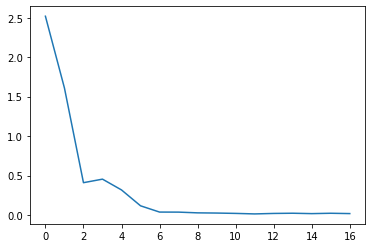

Lowest value: 0.013000000000000005, Index: 11,  T=2048


In [6]:
adress_list= np.array([[1,0],  [1,2], [2,0], [2,2], [4,0], [4,2], [6,0], [6,2]])
adress_list2= np.array([[1,0], [2,0], [4,0], [6,0]])


Theo_Coeff=np.loadtxt('Tables/Theo_Coeff_A1.csv', delimiter=',').T
data_dict = load_multiple_files(base_dir, exn, data_lengths, M_values)


diff = np.zeros(len(data_lengths))
for idx, chosen_time in enumerate(data_lengths):
    All_Coeffs = AllCoeff(N, Theo_Coeff, data_dict, chosen_time, adress_list)
    diff[idx] = np.mean(np.abs(Theo_Coeff- np.array([All_Coeffs[i,:] for i in range(0, len(All_Coeffs), 3)])))

plt.plot(diff)
plt.show()

print(f"Lowest value: {np.min(diff)}, Index: {np.argmin(diff)},  T={data_lengths[np.argmin(diff)]}")
    

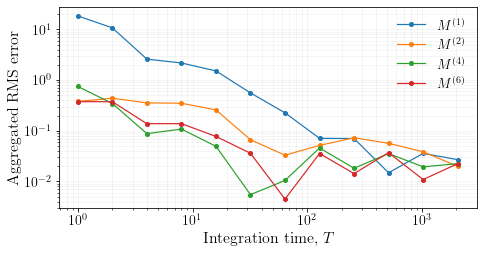

In [8]:
data_lengths_array = timelist=[1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048 ]  # , 4096, 8192, 16384, 32768, 65536
data_lengths = [f"{data_lengths_array[i]}" for i in range(len(data_lengths_array))]
PlotAggregatedMomentErrors(    N,    Theo_Coeff,    data_dict,    data_lengths,    adress_list,    moment_orders=(1, 2, 4, 6),    normalize=False,    eps=1e-12,    title=None, savepath= Examplename)

48 Files read
statistic1 =  0.01937449999999996 ---- p_value1 =  1.0232954642564302e-59


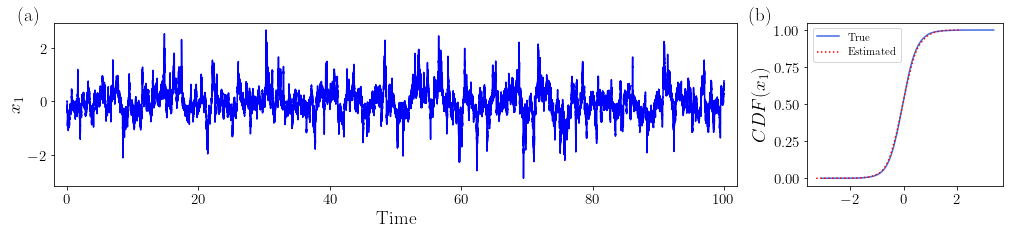

In [19]:
data_lengths_array = timelist=[1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048] 
data_lengths = [f"{data_lengths_array[i]}" for i in range(len(data_lengths_array))]
plotA1(path1, exn, base_dir, data_lengths,data_lengths_array, M_values, Theo_Coeff, Examplename, dt, PT)

In [52]:
chosen_time= data_lengths[np.argmin(diff)]
All_Coeffs = AllCoeff_Table(N, Theo_Coeff, data_dict, chosen_time, adress_list)

Lables = ['\\alpha ', '\phi ', '\\theta' , '\gamma'  ]
Chosen_M = [1,2,3,4]

PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)

$\alpha $&$-0.002\pm0.008$&0&\cellcolor{yellow!25}$1.011\pm0.003$&\cellcolor{yellow!25}1&$-0.001\pm0.002$&0&$-0.003\pm0.002$&0\\
$\phi $&$-0.006\pm0.03$&0&\cellcolor{yellow!25}$0.504\pm0.014$&\cellcolor{yellow!25}0.5&$0.007\pm0.008$&0&$0.013\pm0.008$&0\\
$\theta$&$-0.034\pm0.038$&0&\cellcolor{yellow!25}$5.962\pm0.014$&\cellcolor{yellow!25}6&\cellcolor{yellow!25}$1.545\pm0.006$&\cellcolor{yellow!25}1.5&\cellcolor{yellow!25}$0.793\pm0.007$&\cellcolor{yellow!25}0.75\\
$\gamma$&\cellcolor{yellow!25}$-4.946\pm0.037$&\cellcolor{yellow!25}-5&$0.009\pm0.018$&0&$0.007\pm0.01$&0&$0.005\pm0.009$&0\\


## B1

In [21]:
Examplename="Example B1"
exn="2D_#1_itoSRI2_5E4_dxfTrue"
base_dir = path1 + exn + "/"
ST = 1000  #simulate t
PT = 100   #plot t
N=2;dt=0.0005
nsteps=int(ST/dt)
x0 = np.array([0,0])
method="itoSRI2"

In [8]:
chosentimes = [16, 128, 1024, 16384]
dx_init = 0.01
dx_new = 0.1
PlotMoments(path1, exn, Examplename, chosentimes, dx_init, dx_new)

Maximum nbins found: 1097
Shape after padding: (4, 30, 2, 1097)
New nbins after rebinning: 109
Shape after rebinning: (4, 30, 2, 109)


68 Files read


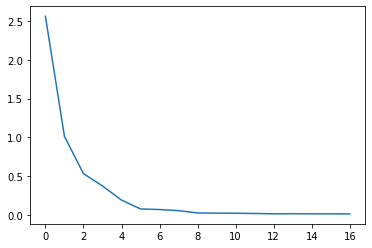

Lowest value: 0.012688281249999989, Index: 16,  T=65536


In [22]:
adress_list= np.array([[1,0], [1,4], [1,1], [1,5], [2,0], [2,6], [2,1], [2,7], [2,2], [2,8], [4,0], [4,6], [4,1], [4,7], [4,2], [4,8], [6,0], [6,8], [6,1], [6,9], [6,2], [6,10], [6,3], [6,11]])
adress_list2= np.array([[1,0], [1,1], [2,0],  [2,1], [2,2], [4,0], [4,1], [4,2], [6,0], [6,1], [6,2], [6,3]])

Theo_Coeff=np.loadtxt('Tables/Theo_Coeff_B1.csv', delimiter=',').T
data_dict = load_multiple_files(base_dir, exn, data_lengths, M_values)

diff = np.zeros(len(data_lengths))
for idx, chosen_time in enumerate(data_lengths):
    All_Coeffs = AllCoeff(N, Theo_Coeff, data_dict, chosen_time, adress_list)
    diff[idx] = np.mean(np.abs(Theo_Coeff- np.array([All_Coeffs[i,:] for i in range(0, len(All_Coeffs), 3)])))

plt.plot(diff)
plt.show()

print(f"Lowest value: {np.min(diff)}, Index: {np.argmin(diff)},  T={data_lengths[np.argmin(diff)]}")

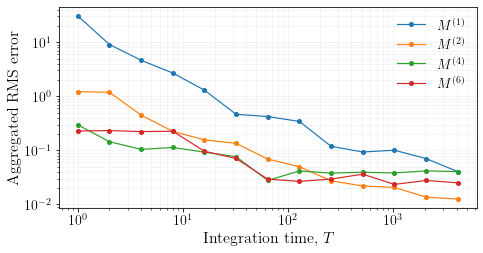

In [23]:
data_lengths_array = timelist=[1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096 ]  # , 8192, 16384, 32768, 65536
data_lengths = [f"{data_lengths_array[i]}" for i in range(len(data_lengths_array))]
PlotAggregatedMomentErrors(N,    Theo_Coeff,    data_dict,    data_lengths,    adress_list,    moment_orders=(1, 2, 4, 6),    normalize=False,    eps=1e-12,    title=None, savepath= Examplename)

52 Files read
statistic1 =  0.08684000000000003 ---- p_value1 =  0.0
statistic2 =  0.03396500000000002 ---- p_value2 =  1.157297846699994e-100


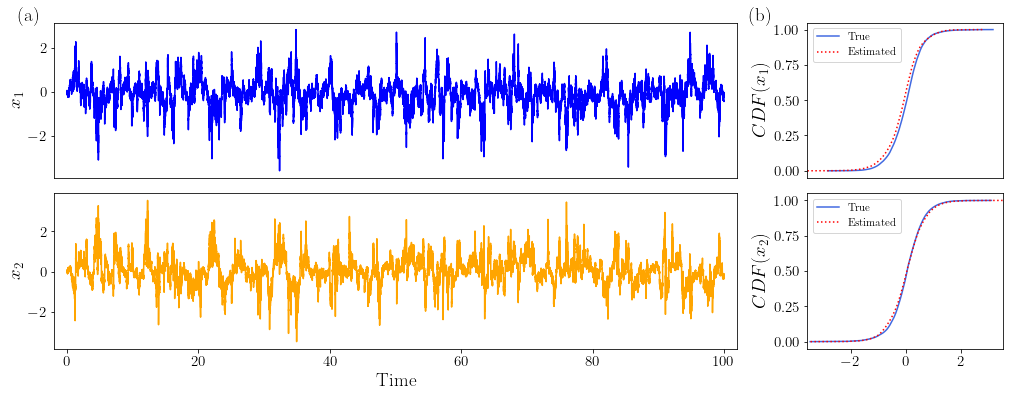

In [24]:
data_lengths_array = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]   # , 8192, 16384, 32768, 65536
data_lengths = [f"{data_lengths_array[i]}" for i in range(len(data_lengths_array))]
plotB1(path1, exn, base_dir, data_lengths,data_lengths_array, M_values, Theo_Coeff, Examplename, dt, PT)

In [18]:
Lables = ['\\alpha',        '\phi_1',        '\phi_2',        '\\theta_{11}' ,        '\\theta_{12}',        '\\theta_{22}' ,        '\gamma_{111}' ,        '\gamma_{112}' ,        '\gamma_{122}' ,        '\gamma_{222}' ]
adress_list= np.array([[1,0], [1,4], [1,1], [1,5], [2,0], [2,6], [2,1], [2,7], [2,2], [2,8], [4,0], [4,6], [4,1], [4,7], [4,2], [4,8], [6,0], [6,8], [6,1], [6,9], [6,2], [6,10], [6,3], [6,11]])
adress_list2= np.array([[1,0], [1,1], [2,0],  [2,1], [2,2], [4,0], [4,1], [4,2], [6,0], [6,1], [6,2], [6,3]])
chosen_time= data_lengths[np.argmin(diff)]
All_Coeffs = AllCoeff_Table(N, Theo_Coeff, data_dict, chosen_time, adress_list)

In [21]:
Chosen_M=np.array([1,2,3,5])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([6,7,8,9])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([10,11,12])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)

$\alpha$&$-0.006\pm0.002$&0&$0.000\pm0.002$&0&\cellcolor{yellow!25}$0.708\pm0.001$&\cellcolor{yellow!25}0.7&\cellcolor{yellow!25}$0.307\pm0.001$&\cellcolor{yellow!25}0.3\\
$\phi_1$&$-0.089\pm0.006$&0&\cellcolor{yellow!25}$-3.01\pm0.006$&\cellcolor{yellow!25}-3&$-0.003\pm0.003$&0&$0.002\pm0.003$&0\\
$\phi_2$&\cellcolor{yellow!25}$-2.003\pm0.006$&\cellcolor{yellow!25}-2&$-0.07\pm0.006$&0&$-0.001\pm0.002$&0&$0.008\pm0.004$&0\\
$\theta_{11}$&$0.012\pm0.007$&0&$-0.005\pm0.006$&0&\cellcolor{yellow!25}$5.966\pm0.003$&\cellcolor{yellow!25}6&\cellcolor{yellow!25}$5.738\pm0.003$&\cellcolor{yellow!25}5.75\\
$\theta_{22}$&$0.004\pm0.007$&0&$-0.002\pm0.006$&0&\cellcolor{yellow!25}$3.117\pm0.002$&\cellcolor{yellow!25}3.125&\cellcolor{yellow!25}$4.842\pm0.004$&\cellcolor{yellow!25}4.875\\
$\gamma_{111}$&\cellcolor{yellow!25}$-4.891\pm0.005$&\cellcolor{yellow!25}-5&$-0.003\pm0.005$&0&$0.001\pm0.003$&0&$-0.003\pm0.003$&0\\
$\gamma_{222}$&$0.003\pm0.005$&0&\cellcolor{yellow!25}$-4.899\pm0.004$&\cellcolo

In [20]:
Chosen_M=np.array([1,2,3,4])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([5,6,7,8])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([9,10,11,12])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)

$\alpha$&$-0.006\pm0.002$&0&$0.000\pm0.002$&0&\cellcolor{yellow!25}$0.708\pm0.001$&\cellcolor{yellow!25}0.7&$0.000\pm0.001$&0\\
$\phi_1$&$-0.089\pm0.006$&0&\cellcolor{yellow!25}$-3.01\pm0.006$&\cellcolor{yellow!25}-3&$-0.003\pm0.003$&0&$0.002\pm0.002$&0\\
$\phi_2$&\cellcolor{yellow!25}$-2.003\pm0.006$&\cellcolor{yellow!25}-2&$-0.07\pm0.006$&0&$-0.001\pm0.002$&0&$0.000\pm0.001$&0\\
$\theta_{11}$&$0.012\pm0.007$&0&$-0.005\pm0.006$&0&\cellcolor{yellow!25}$5.966\pm0.003$&\cellcolor{yellow!25}6&$-0.006\pm0.002$&0\\
$\theta_{12}$&$0.012\pm0.009$&0&$-0.008\pm0.008$&0&$0.011\pm0.003$&0&$0.001\pm0.002$&0\\
$\theta_{22}$&$0.004\pm0.007$&0&$-0.002\pm0.006$&0&\cellcolor{yellow!25}$3.117\pm0.002$&\cellcolor{yellow!25}3.125&$-0.001\pm0.001$&0\\
$\gamma_{111}$&\cellcolor{yellow!25}$-4.891\pm0.005$&\cellcolor{yellow!25}-5&$-0.003\pm0.005$&0&$0.001\pm0.003$&0&$0.002\pm0.002$&0\\
$\gamma_{112}$&$0.015\pm0.011$&0&$-0.021\pm0.013$&0&$-0.001\pm0.004$&0&$0.003\pm0.003$&0\\
$\gamma_{122}$&$-0.005\pm0.007$&0&

In [ ]:

Chosen_M=np.array([1,2,3,4,5,6])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([7,8,9,10,11,12])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)

$\alpha$&$-0.006\pm0.002$&0&$0.000\pm0.002$&0&\cellcolor{yellow!25}$0.708\pm0.001$&\cellcolor{yellow!25}0.7&$0.000\pm0.001$&0&\cellcolor{yellow!25}$0.307\pm0.001$&\cellcolor{yellow!25}0.3&$-0.031\pm0.000$&0\\
$\phi_1$&$-0.089\pm0.006$&0&\cellcolor{yellow!25}$-3.01\pm0.006$&\cellcolor{yellow!25}-3&$-0.003\pm0.003$&0&$0.002\pm0.002$&0&$0.002\pm0.003$&0&$-0.002\pm0.002$&0\\
$\phi_2$&\cellcolor{yellow!25}$-2.003\pm0.006$&\cellcolor{yellow!25}-2&$-0.07\pm0.006$&0&$-0.001\pm0.002$&0&$0.000\pm0.001$&0&$0.008\pm0.004$&0&$-0.002\pm0.001$&0\\
$\theta_{11}$&$0.012\pm0.007$&0&$-0.005\pm0.006$&0&\cellcolor{yellow!25}$5.966\pm0.003$&\cellcolor{yellow!25}6&$-0.006\pm0.002$&0&\cellcolor{yellow!25}$5.738\pm0.003$&\cellcolor{yellow!25}5.75&\cellcolor{yellow!25}$1.598\pm0.002$&\cellcolor{yellow!25}1.5\\
$\theta_{22}$&$0.004\pm0.007$&0&$-0.002\pm0.006$&0&\cellcolor{yellow!25}$3.117\pm0.002$&\cellcolor{yellow!25}3.125&$-0.001\pm0.001$&0&\cellcolor{yellow!25}$4.842\pm0.004$&\cellcolor{yellow!25}4.875&\cellc

In [92]:
Lables = ['\\alpha',        '\phi_1',        '\phi_2',        '\\theta_{11}' ,        '\\theta_{12}',        '\\theta_{22}' ,        '\gamma_{111}' ,        '\gamma_{112}' ,        '\gamma_{122}' ,        '\gamma_{222}' ]
adress_list= np.array([[1,0], [1,4], [1,1], [1,5], [2,0], [2,6], [2,1], [2,7], [2,2], [2,8], [4,0], [4,6], [4,1], [4,7], [4,2], [4,8], [6,0], [6,8], [6,1], [6,9], [6,2], [6,10], [6,3], [6,11]])
adress_list2= np.array([[1,0], [1,1], [2,0],  [2,1], [2,2], [4,0], [4,1], [4,2], [6,0], [6,1], [6,2], [6,3]])
chosen_time= "4096"
All_Coeffs = AllCoeff_Table(N, Theo_Coeff, data_dict, chosen_time, adress_list)

Chosen_M=np.array([1,2,3,4,5,6])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([7,8,9,10,11,12])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)

$\alpha$&$0.007\pm0.01$&0&$0.015\pm0.009$&0&\cellcolor{yellow!25}$0.702\pm0.003$&\cellcolor{yellow!25}0.7&$-0.002\pm0.002$&0&\cellcolor{yellow!25}$0.31\pm0.003$&\cellcolor{yellow!25}0.3&$-0.036\pm0.002$&0\\
$\phi_1$&$-0.017\pm0.026$&0&\cellcolor{yellow!25}$-3.023\pm0.029$&\cellcolor{yellow!25}-3&$0.003\pm0.011$&0&$0.017\pm0.006$&0&$-0.018\pm0.015$&0&$0.005\pm0.007$&0\\
$\phi_2$&\cellcolor{yellow!25}$-2.028\pm0.023$&\cellcolor{yellow!25}-2&$-0.02\pm0.026$&0&$-0.007\pm0.009$&0&$0.003\pm0.006$&0&$0.014\pm0.013$&0&$-0.007\pm0.006$&0\\
$\theta_{11}$&$-0.044\pm0.026$&0&$-0.059\pm0.026$&0&\cellcolor{yellow!25}$5.962\pm0.011$&\cellcolor{yellow!25}6&$-0.004\pm0.007$&0&\cellcolor{yellow!25}$5.757\pm0.01$&\cellcolor{yellow!25}5.75&\cellcolor{yellow!25}$1.595\pm0.007$&\cellcolor{yellow!25}1.5\\
$\theta_{12}$&$-0.046\pm0.031$&0&$0.034\pm0.032$&0&$0.013\pm0.014$&0&$-0.02\pm0.009$&0&$0.013\pm0.014$&0&$-0.02\pm0.009$&0\\
$\theta_{22}$&$0.006\pm0.019$&0&$-0.008\pm0.027$&0&\cellcolor{yellow!25}$3.123\pm

In [90]:
Lables = ['\\alpha',        '\phi_1',        '\phi_2',        '\\theta_{11}' ,        '\\theta_{12}',        '\\theta_{22}' ,        '\gamma_{111}' ,        '\gamma_{112}' ,        '\gamma_{122}' ,        '\gamma_{222}' ]
adress_list= np.array([[1,0], [1,4], [1,1], [1,5], [2,0], [2,6], [2,1], [2,7], [2,2], [2,8], [4,0], [4,6], [4,1], [4,7], [4,2], [4,8], [6,0], [6,8], [6,1], [6,9], [6,2], [6,10], [6,3], [6,11]])
adress_list2= np.array([[1,0], [1,1], [2,0],  [2,1], [2,2], [4,0], [4,1], [4,2], [6,0], [6,1], [6,2], [6,3]])
chosen_time= data_lengths[np.argmin(diff)]
All_Coeffs = AllCoeff_Table(N, Theo_Coeff, data_dict, chosen_time, adress_list)

Chosen_M=np.array([1,2,3,4,5,6])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([7,8,9,10,11,12])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)

$\alpha$&$-0.006\pm0.002$&0&$0.000\pm0.002$&0&\cellcolor{yellow!25}$0.708\pm0.001$&\cellcolor{yellow!25}0.7&$0.000\pm0.001$&0&\cellcolor{yellow!25}$0.307\pm0.001$&\cellcolor{yellow!25}0.3&$-0.031\pm0.000$&0\\
$\phi_1$&$-0.089\pm0.006$&0&\cellcolor{yellow!25}$-3.01\pm0.006$&\cellcolor{yellow!25}-3&$-0.003\pm0.003$&0&$0.002\pm0.002$&0&$0.002\pm0.003$&0&$-0.002\pm0.002$&0\\
$\phi_2$&\cellcolor{yellow!25}$-2.003\pm0.006$&\cellcolor{yellow!25}-2&$-0.07\pm0.006$&0&$-0.001\pm0.002$&0&$0.000\pm0.001$&0&$0.008\pm0.004$&0&$-0.002\pm0.001$&0\\
$\theta_{11}$&$0.012\pm0.007$&0&$-0.005\pm0.006$&0&\cellcolor{yellow!25}$5.966\pm0.003$&\cellcolor{yellow!25}6&$-0.006\pm0.002$&0&\cellcolor{yellow!25}$5.738\pm0.003$&\cellcolor{yellow!25}5.75&\cellcolor{yellow!25}$1.598\pm0.002$&\cellcolor{yellow!25}1.5\\
$\theta_{12}$&$0.012\pm0.009$&0&$-0.008\pm0.008$&0&$0.011\pm0.003$&0&$0.001\pm0.002$&0&$0.002\pm0.005$&0&$-0.026\pm0.003$&0\\
$\theta_{22}$&$0.004\pm0.007$&0&$-0.002\pm0.006$&0&\cellcolor{yellow!25}$3.117

## B2

In [26]:
Examplename="Example B2"
exn="2D_#2_itoSRI2_5E4_dxfTrue"
base_dir = path1 + exn + "/"
ST = 10000  #simulate t
PT = 1000   #plot t
N=2;dt=0.0005
nsteps=int(ST/dt)
x0 = np.array([0,0])
method="itoSRI2"

In [16]:
chosentimes = [16, 128, 1024, 65536]
dx_init = 0.01
dx_new = 0.1
PlotMoments(path1, exn, Examplename, chosentimes, dx_init, dx_new)

Maximum nbins found: 1517
Shape after padding: (4, 30, 2, 1517)
New nbins after rebinning: 151
Shape after rebinning: (4, 30, 2, 151)


68 Files read


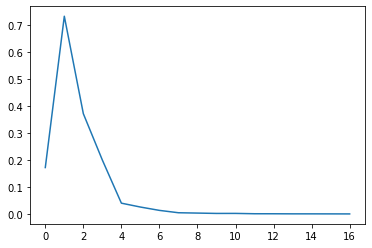

Lowest value: 0.00016077777777777556, Index: 16,  T=65536


In [27]:
adress_list= np.array([[1,0], [1,4], [1,1], [1,5], [2,0], [2,6], [2,1], [2,7], [2,2], [2,8], [4,0], [4,6], [4,1], [4,7], [4,2], [4,8], [6,0], [6,8], [6,1], [6,9], [6,2], [6,10], [6,3], [6,11]])
adress_list2= np.array([[1,0], [1,1], [2,0],  [2,1], [2,2], [4,0], [4,1], [4,2], [6,0], [6,1], [6,2], [6,3]])

Theo_Coeff=np.loadtxt('Tables/Theo_Coeff_B2.csv', delimiter=',').T
data_dict = load_multiple_files(base_dir, exn, data_lengths, M_values)

diff = np.zeros(len(data_lengths))
for idx, chosen_time in enumerate(data_lengths):
    All_Coeffs = AllCoeff(N, Theo_Coeff, data_dict, chosen_time, adress_list)
    diff[idx] = np.mean(np.abs(Theo_Coeff- np.array([All_Coeffs[i,:] for i in range(0, len(All_Coeffs), 3)])))

plt.plot(diff)
plt.show()

print(f"Lowest value: {np.min(diff)}, Index: {np.argmin(diff)},  T={data_lengths[np.argmin(diff)]}")


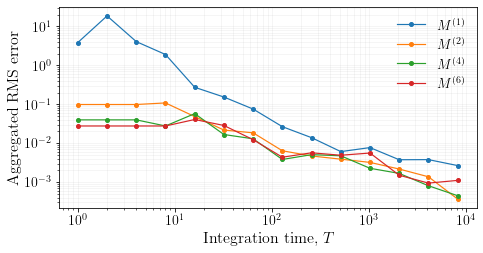

In [28]:
data_lengths_array = timelist=[1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192 ]  # , 16384, 32768, 65536
data_lengths = [f"{data_lengths_array[i]}" for i in range(len(data_lengths_array))]

PlotAggregatedMomentErrors(N,    Theo_Coeff,    data_dict,    data_lengths,    adress_list,    moment_orders=(1, 2, 4, 6),    normalize=False,    eps=1e-12,    title=None, savepath= Examplename)

68 Files read
statistic1 =  0.013895550000000007 ---- p_value1 =  0.0
statistic2 =  0.01637255000000004 ---- p_value2 =  0.0


C:\Users\Abolfazl\AppData\Local\Temp\ipykernel_8180\2128519299.py:965: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("D:/U/M/M-P/codes and res/Ultimate_Examples/Plots/"+Examplename+"_All_M.pdf", dpi=600, bbox_inches="tight")
C:\Users\Abolfazl\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


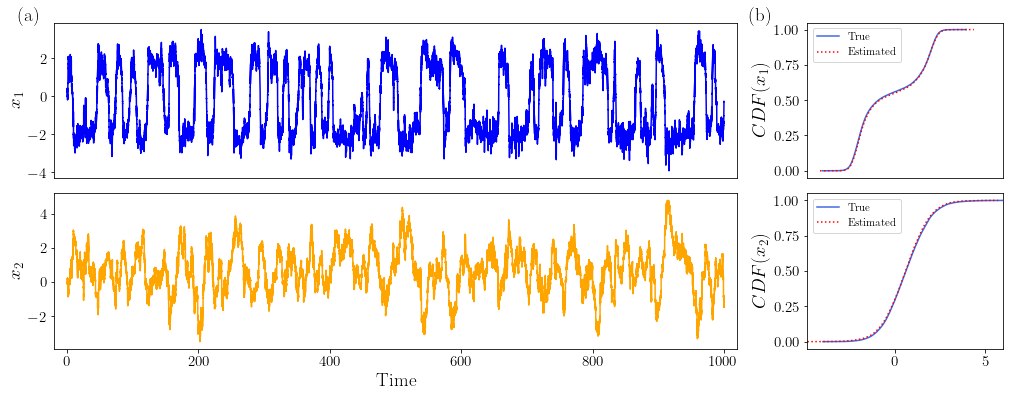

In [29]:
data_lengths_array = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536]   # [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
data_lengths = [f"{data_lengths_array[i]}" for i in range(len(data_lengths_array))]
plotB1(path1, exn, base_dir, data_lengths,data_lengths_array, M_values, Theo_Coeff, Examplename, dt, PT)

In [ ]:
Lables = ['\\alpha',        '\phi_1',        '\phi_2',        '\\theta_{11}' ,        '\\theta_{12}',        '\\theta_{22}' ,        '\gamma_{111}' ,        '\gamma_{112}' ,        '\gamma_{122}' ,        '\gamma_{222}' ]
adress_list= np.array([[1,0], [1,4], [1,1], [1,5], [2,0], [2,6], [2,1], [2,7], [2,2], [2,8], [4,0], [4,6], [4,1], [4,7], [4,2], [4,8], [6,0], [6,8], [6,1], [6,9], [6,2], [6,10], [6,3], [6,11]])
adress_list2= np.array([[1,0], [1,1], [2,0],  [2,1], [2,2], [4,0], [4,1], [4,2], [6,0], [6,1], [6,2], [6,3]])
chosen_time= data_lengths[np.argmin(diff)]
All_Coeffs = AllCoeff_Table(N, Theo_Coeff, data_dict, chosen_time, adress_list)

In [27]:
Chosen_M=np.array([1,2,3,4])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([5,6,7,8])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([9,10,11,12])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)

$\alpha$&\cellcolor{yellow!25}$0.499\pm0.001$&\cellcolor{yellow!25}0.5&\cellcolor{yellow!25}$0.057\pm0.001$&\cellcolor{yellow!25}0.056&\cellcolor{yellow!25}$0.421\pm0.001$&\cellcolor{yellow!25}0.42&$0.000\pm0.000$&0\\
$\phi_1$&\cellcolor{yellow!25}$1.0\pm0.001$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$0.08\pm0.001$&\cellcolor{yellow!25}0.08&$0.000\pm0.001$&0&$0.000\pm0.000$&0\\
$\phi_2$&\cellcolor{yellow!25}$-1.001\pm0.001$&\cellcolor{yellow!25}-1&\cellcolor{yellow!25}$-0.059\pm0.001$&\cellcolor{yellow!25}-0.06&$0.000\pm0.001$&0&$0.000\pm0.000$&0\\
$\gamma_{111}$&\cellcolor{yellow!25}$-0.333\pm0.000$&\cellcolor{yellow!25}-0.333&$0.000\pm0.000$&0&$0.000\pm0.000$&0&$0.000\pm0.000$&0\\
______________________________________________________________________________
$\alpha$&\cellcolor{yellow!25}$0.339\pm0.001$&\cellcolor{yellow!25}0.34&\cellcolor{yellow!25}$0.169\pm0.001$&\cellcolor{yellow!25}0.169&\cellcolor{yellow!25}$0.027\pm0.000$&\cellcolor{yellow!25}0.027&\cellcolor{yellow!25}$0.1

In [26]:
Chosen_M=np.array([1,2,3,4])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([5,6,7,8])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([9,10,11,12])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)

$\alpha$&\cellcolor{yellow!25}$0.499\pm0.001$&\cellcolor{yellow!25}0.5&\cellcolor{yellow!25}$0.057\pm0.001$&\cellcolor{yellow!25}0.056&\cellcolor{yellow!25}$0.421\pm0.001$&\cellcolor{yellow!25}0.42&$0.000\pm0.000$&0\\
$\phi_1$&\cellcolor{yellow!25}$1.0\pm0.001$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$0.08\pm0.001$&\cellcolor{yellow!25}0.08&$0.000\pm0.001$&0&$0.000\pm0.000$&0\\
$\phi_2$&\cellcolor{yellow!25}$-1.001\pm0.001$&\cellcolor{yellow!25}-1&\cellcolor{yellow!25}$-0.059\pm0.001$&\cellcolor{yellow!25}-0.06&$0.000\pm0.001$&0&$0.000\pm0.000$&0\\
$\theta_{11}$&$0.000\pm0.000$&0&$0.000\pm0.000$&0&$0.000\pm0.000$&0&$0.000\pm0.000$&0\\
$\theta_{12}$&$0.000\pm0.000$&0&$0.001\pm0.001$&0&$0.000\pm0.000$&0&$0.000\pm0.000$&0\\
$\theta_{22}$&$0.000\pm0.000$&0&$0.000\pm0.001$&0&$0.000\pm0.000$&0&$0.000\pm0.000$&0\\
$\gamma_{111}$&\cellcolor{yellow!25}$-0.333\pm0.000$&\cellcolor{yellow!25}-0.333&$0.000\pm0.000$&0&$0.000\pm0.000$&0&$0.000\pm0.000$&0\\
$\gamma_{112}$&$0.001\pm0.000$&0&$-0.001

In [ ]:

Chosen_M=np.array([1,2,3,4,5,6])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([7,8,9,10,11,12])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)

$\alpha$&\cellcolor{yellow!25}$0.499\pm0.001$&\cellcolor{yellow!25}0.5&\cellcolor{yellow!25}$0.057\pm0.001$&\cellcolor{yellow!25}0.056&\cellcolor{yellow!25}$0.421\pm0.001$&\cellcolor{yellow!25}0.42&$0.000\pm0.000$&0&\cellcolor{yellow!25}$0.339\pm0.001$&\cellcolor{yellow!25}0.34&\cellcolor{yellow!25}$0.169\pm0.001$&\cellcolor{yellow!25}0.169\\
$\phi_1$&\cellcolor{yellow!25}$1.0\pm0.001$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$0.08\pm0.001$&\cellcolor{yellow!25}0.08&$0.000\pm0.001$&0&$0.000\pm0.000$&0&$0.000\pm0.001$&0&$0.001\pm0.001$&0\\
$\phi_2$&\cellcolor{yellow!25}$-1.001\pm0.001$&\cellcolor{yellow!25}-1&\cellcolor{yellow!25}$-0.059\pm0.001$&\cellcolor{yellow!25}-0.06&$0.000\pm0.001$&0&$0.000\pm0.000$&0&$0.000\pm0.001$&0&$0.000\pm0.001$&0\\
$\gamma_{111}$&\cellcolor{yellow!25}$-0.333\pm0.000$&\cellcolor{yellow!25}-0.333&$0.000\pm0.000$&0&$0.000\pm0.000$&0&$0.000\pm0.000$&0&$0.000\pm0.000$&0&$0.000\pm0.000$&0\\
_____________________________________________________________________

In [100]:
Lables = ['\\alpha',        '\phi_1',        '\phi_2',        '\\theta_{11}' ,        '\\theta_{12}',        '\\theta_{22}' ,        '\gamma_{111}' ,        '\gamma_{112}' ,        '\gamma_{122}' ,        '\gamma_{222}' ]
adress_list= np.array([[1,0], [1,4], [1,1], [1,5], [2,0], [2,6], [2,1], [2,7], [2,2], [2,8], [4,0], [4,6], [4,1], [4,7], [4,2], [4,8], [6,0], [6,8], [6,1], [6,9], [6,2], [6,10], [6,3], [6,11]])
adress_list2= np.array([[1,0], [1,1], [2,0],  [2,1], [2,2], [4,0], [4,1], [4,2], [6,0], [6,1], [6,2], [6,3]])
chosen_time= data_lengths[np.argmin(diff)]
All_Coeffs = AllCoeff_Table(N, Theo_Coeff, data_dict, chosen_time, adress_list)

Chosen_M=np.array([1,2,3,4,5,6])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([7,8,9,10,11,12])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)

$\alpha$&\cellcolor{yellow!25}$0.499\pm0.001$&\cellcolor{yellow!25}0.5&\cellcolor{yellow!25}$0.057\pm0.001$&\cellcolor{yellow!25}0.056&\cellcolor{yellow!25}$0.421\pm0.001$&\cellcolor{yellow!25}0.42&$0.000\pm0.000$&0&\cellcolor{yellow!25}$0.339\pm0.001$&\cellcolor{yellow!25}0.34&\cellcolor{yellow!25}$0.169\pm0.001$&\cellcolor{yellow!25}0.169\\
$\phi_1$&\cellcolor{yellow!25}$1.0\pm0.001$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$0.08\pm0.001$&\cellcolor{yellow!25}0.08&$0.000\pm0.001$&0&$0.000\pm0.000$&0&$0.000\pm0.001$&0&$0.001\pm0.001$&0\\
$\phi_2$&\cellcolor{yellow!25}$-1.001\pm0.001$&\cellcolor{yellow!25}-1&\cellcolor{yellow!25}$-0.059\pm0.001$&\cellcolor{yellow!25}-0.06&$0.000\pm0.001$&0&$0.000\pm0.000$&0&$0.000\pm0.001$&0&$0.000\pm0.001$&0\\
$\theta_{11}$&$0.000\pm0.000$&0&$0.000\pm0.000$&0&$0.000\pm0.000$&0&$0.000\pm0.000$&0&$0.000\pm0.000$&0&$0.000\pm0.000$&0\\
$\theta_{12}$&$0.000\pm0.000$&0&$0.001\pm0.001$&0&$0.000\pm0.000$&0&$0.000\pm0.000$&0&$0.000\pm0.000$&0&$0.000\pm0.000

## C1

In [37]:
Examplename="Example C1"
exn="3D_#1_itoSRI2_5E4_dxfTrue"
base_dir = path1 + exn + "/"
ST = 1000  #simulate t
PT = 10   #plot t
N=3;dt=0.0005
nsteps=int(ST/dt)
x0 = np.array([0,0,0])
method="itoSRI2"

In [17]:
chosentimes = [16, 128, 1024, 65536]
dx_init = 0.01
dx_new = 0.1
PlotMoments(path1, exn, Examplename, chosentimes, dx_init, dx_new)

Maximum nbins found: 1057
Shape after padding: (4, 30, 3, 1057)
New nbins after rebinning: 105
Shape after rebinning: (4, 30, 3, 105)


68 Files read


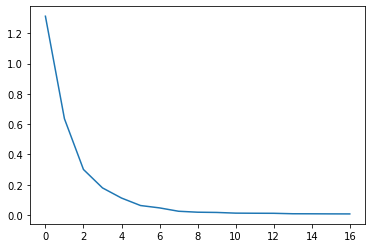

Lowest value: 0.0068918, Index: 16,  T=65536


In [38]:
adress_list, adress_list2 = GetAdressList(N)
Theo_Coeff=np.loadtxt('Tables/Theo_Coeff_C1.csv', delimiter=',').T
data_dict = load_multiple_files(base_dir, exn, data_lengths, M_values)

diff = np.zeros(len(data_lengths))
for idx, chosen_time in enumerate(data_lengths):
    All_Coeffs = AllCoeff(N, Theo_Coeff, data_dict, chosen_time, adress_list)
    diff[idx] = np.mean(np.abs(Theo_Coeff- np.array([All_Coeffs[i,:] for i in range(0, len(All_Coeffs), 3)])))

plt.plot(diff)
plt.show()

print(f"Lowest value: {np.min(diff)}, Index: {np.argmin(diff)},  T={data_lengths[np.argmin(diff)]}")


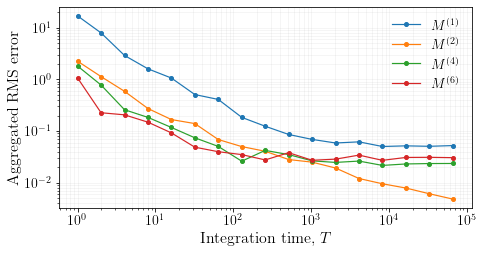

In [39]:
data_lengths_array = timelist=[1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536 ]  # 
data_lengths = [f"{data_lengths_array[i]}" for i in range(len(data_lengths_array))]
PlotAggregatedMomentErrors(N,    Theo_Coeff,    data_dict,    data_lengths,    adress_list,    moment_orders=(1, 2, 4, 6),    normalize=False,    eps=1e-12,    title=None, savepath= Examplename)

statistic1 =  0.008267000000000024 ---- p_value1 =  8.620281079962642e-60
statistic2 =  0.008563500000000057 ---- p_value2 =  3.9886860302713486e-64
statistic3 =  0.012274500000000022 ---- p_value3 =  2.6828723088537113e-131


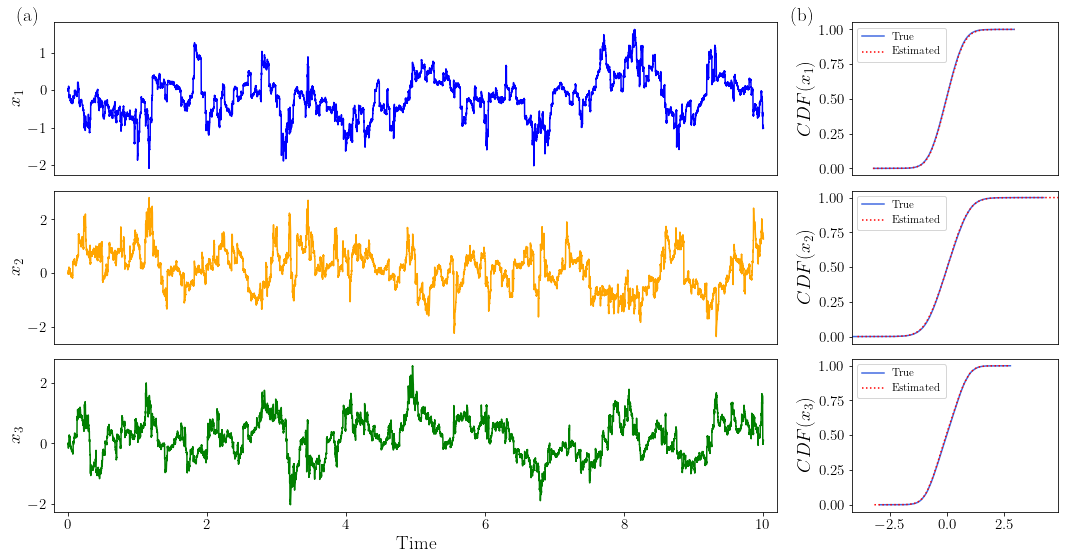

In [40]:
data_lengths_array = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536]   # [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
data_lengths = [f"{data_lengths_array[i]}" for i in range(len(data_lengths_array))]
plotC1(path1, exn, base_dir, data_lengths,data_lengths_array, M_values, Theo_Coeff, Examplename, dt, PT)

In [31]:
Lables = ['\\alpha',        '\phi_1',        '\phi_2',        '\phi_3',     '\\theta_{11}' ,        '\\theta_{12}',        '\\theta_{13}' ,        '\\theta_{22}' ,        '\\theta_{23}' ,        '\\theta_{33}' ,        '\gamma_{111}' ,        '\gamma_{112}' ,        '\gamma_{113}' ,        '\gamma_{122}' ,        '\gamma_{123}' ,        '\gamma_{133}' ,        '\gamma_{222}',        '\gamma_{223}' ,        '\gamma_{233}' ,        '\gamma_{333}'       ]
adress_list, adress_list2 = GetAdressList(N)
chosen_time= data_lengths[np.argmin(diff)]
All_Coeffs = AllCoeff_Table(N, Theo_Coeff, data_dict, chosen_time, adress_list)


In [32]:

Chosen_M=np.array([1,2,3,4,5])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([6,7,8,9,10])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([11,12,13,14,15])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([16,17,18,19,20])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([21, 22, 23, 24, 25])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)



$\alpha$&$0.003\pm0.003$&0&$-0.004\pm0.004$&0&$0.005\pm0.003$&0&\cellcolor{yellow!25}$1.954\pm0.001$&\cellcolor{yellow!25}1.95&$0.000\pm0.001$&0\\
$\phi_1$&$-0.088\pm0.005$&0&\cellcolor{yellow!25}$-3.027\pm0.007$&\cellcolor{yellow!25}-3&\cellcolor{yellow!25}$-0.993\pm0.006$&\cellcolor{yellow!25}-1&$-0.012\pm0.003$&0&$0.006\pm0.001$&0\\
$\phi_2$&\cellcolor{yellow!25}$-1.997\pm0.005$&\cellcolor{yellow!25}-2&$-0.202\pm0.007$&0&\cellcolor{yellow!25}$-0.999\pm0.005$&\cellcolor{yellow!25}-1&$-0.006\pm0.002$&0&$0.001\pm0.002$&0\\
$\phi_3$&\cellcolor{yellow!25}$-1.0\pm0.004$&\cellcolor{yellow!25}-1&\cellcolor{yellow!25}$0.991\pm0.005$&\cellcolor{yellow!25}1&$-0.082\pm0.005$&0&$0.000\pm0.002$&0&$0.001\pm0.001$&0\\
$\theta_{11}$&$0.003\pm0.006$&0&$-0.006\pm0.006$&0&$-0.008\pm0.005$&0&\cellcolor{yellow!25}$4.484\pm0.003$&\cellcolor{yellow!25}4.5&$0.002\pm0.001$&0\\
$\theta_{22}$&$-0.004\pm0.003$&0&$0.003\pm0.006$&0&$-0.007\pm0.004$&0&\cellcolor{yellow!25}$1.751\pm0.001$&\cellcolor{yellow!25}1.75&

In [ ]:

Chosen_M=np.array([1,2,3,4,5])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([6,7,8,9,10])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([11,12,13,14,15])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([16,17,18,19,20])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([21, 22, 23, 24, 25])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)



$\alpha$&$0.003\pm0.003$&0&$-0.004\pm0.004$&0&$0.005\pm0.003$&0&\cellcolor{yellow!25}$1.954\pm0.001$&\cellcolor{yellow!25}1.95&$0.000\pm0.001$&0\\
$\phi_1$&$-0.088\pm0.005$&0&\cellcolor{yellow!25}$-3.027\pm0.007$&\cellcolor{yellow!25}-3&\cellcolor{yellow!25}$-0.993\pm0.006$&\cellcolor{yellow!25}-1&$-0.012\pm0.003$&0&$0.006\pm0.001$&0\\
$\phi_2$&\cellcolor{yellow!25}$-1.997\pm0.005$&\cellcolor{yellow!25}-2&$-0.202\pm0.007$&0&\cellcolor{yellow!25}$-0.999\pm0.005$&\cellcolor{yellow!25}-1&$-0.006\pm0.002$&0&$0.001\pm0.002$&0\\
$\phi_3$&\cellcolor{yellow!25}$-1.0\pm0.004$&\cellcolor{yellow!25}-1&\cellcolor{yellow!25}$0.991\pm0.005$&\cellcolor{yellow!25}1&$-0.082\pm0.005$&0&$0.000\pm0.002$&0&$0.001\pm0.001$&0\\
$\theta_{11}$&$0.003\pm0.006$&0&$-0.006\pm0.006$&0&$-0.008\pm0.005$&0&\cellcolor{yellow!25}$4.484\pm0.003$&\cellcolor{yellow!25}4.5&$0.002\pm0.001$&0\\
$\theta_{12}$&$-0.009\pm0.005$&0&$0.016\pm0.009$&0&$-0.009\pm0.007$&0&$0.004\pm0.003$&0&$0.000\pm0.001$&0\\
$\theta_{13}$&$-0.01\pm0.

In [100]:
Lables = ['\\alpha',        '\phi_1',        '\phi_2',        '\phi_3',     '\\theta_{11}' ,        '\\theta_{12}',        '\\theta_{13}' ,        '\\theta_{22}' ,        '\\theta_{23}' ,        '\\theta_{33}' ,        '\gamma_{111}' ,        '\gamma_{112}' ,        '\gamma_{113}' ,        '\gamma_{122}' ,        '\gamma_{123}' ,        '\gamma_{133}' ,        '\gamma_{222}',        '\gamma_{223}' ,        '\gamma_{233}' ,        '\gamma_{333}'       ]
adress_list, adress_list2 = GetAdressList(N)
chosen_time= data_lengths[np.argmin(diff)]
All_Coeffs = AllCoeff_Table(N, Theo_Coeff, data_dict, chosen_time, adress_list)

Chosen_M=np.array([1,2,3,4,5])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([6,7,8,9,10])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([11,12,13,14,15])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([16,17,18,19,20])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([21, 22, 23, 24, 25])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)



$\alpha$&$0.003\pm0.003$&0&$-0.004\pm0.004$&0&$0.005\pm0.003$&0&$1.954\pm0.001$&1.95&$0.000\pm0.001$&0\\
$\phi_1$&$-0.088\pm0.005$&0&$-3.027\pm0.007$&-3&$-0.993\pm0.006$&-1&$-0.012\pm0.003$&0&$0.006\pm0.001$&0\\
$\phi_2$&$-1.997\pm0.005$&-2&$-0.202\pm0.007$&0&$-0.999\pm0.005$&-1&$-0.006\pm0.002$&0&$0.001\pm0.002$&0\\
$\phi_3$&$-1.0\pm0.004$&-1&$0.991\pm0.005$&1&$-0.082\pm0.005$&0&$0.000\pm0.002$&0&$0.001\pm0.001$&0\\
$\theta_{11}$&$0.003\pm0.006$&0&$-0.006\pm0.006$&0&$-0.008\pm0.005$&0&$4.484\pm0.003$&4.5&$0.002\pm0.001$&0\\
$\theta_{12}$&$-0.009\pm0.005$&0&$0.016\pm0.009$&0&$-0.009\pm0.007$&0&$0.004\pm0.003$&0&$0.000\pm0.001$&0\\
$\theta_{13}$&$-0.01\pm0.005$&0&$0.006\pm0.007$&0&$-0.002\pm0.004$&0&$0.004\pm0.002$&0&$0.002\pm0.001$&0\\
$\theta_{22}$&$-0.004\pm0.003$&0&$0.003\pm0.006$&0&$-0.007\pm0.004$&0&$1.751\pm0.001$&1.75&$-0.002\pm0.001$&0\\
$\theta_{23}$&$0.001\pm0.004$&0&$0.011\pm0.007$&0&$0.012\pm0.005$&0&$-0.001\pm0.001$&0&$0.002\pm0.001$&0\\
$\theta_{33}$&$0.003\pm0.004$&0&$0.

## C2

In [42]:
Examplename="Example C2"
exn="3D_#2_itoSRI2_5E4_dxfTrue"
base_dir = path1 + exn + "/"
ST = 1000  #simulate t
PT = 100   #plot t
N=3;dt=0.0005
nsteps=int(ST/dt)
x0 = np.array([0,0,0])
method="itoSRI2"

In [9]:
chosentimes = [16, 128, 1024, 65536]
dx_init = 0.01
dx_new = 0.1
PlotMoments(path1, exn, Examplename, chosentimes, dx_init, dx_new)

Maximum nbins found: 2553
Shape after padding: (4, 30, 3, 2553)
New nbins after rebinning: 255
Shape after rebinning: (4, 30, 3, 255)


68 Files read


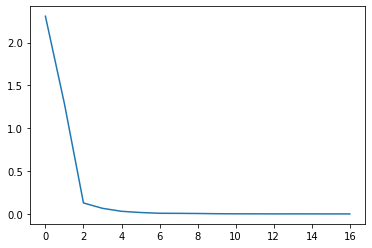

Lowest value: 0.00034399999999999985, Index: 16,  T=65536


In [43]:
adress_list, adress_list2 = GetAdressList(N)
Theo_Coeff=np.loadtxt('Tables/Theo_Coeff_C2.csv', delimiter=',').T
data_dict = load_multiple_files(base_dir, exn, data_lengths, M_values)

diff = np.zeros(len(data_lengths))
for idx, chosen_time in enumerate(data_lengths):
    All_Coeffs = AllCoeff(N, Theo_Coeff, data_dict, chosen_time, adress_list)
    diff[idx] = np.mean(np.abs(Theo_Coeff- np.array([All_Coeffs[i,:] for i in range(0, len(All_Coeffs), 3)])))

plt.plot(diff)
plt.show()

print(f"Lowest value: {np.min(diff)}, Index: {np.argmin(diff)},  T={data_lengths[np.argmin(diff)]}")

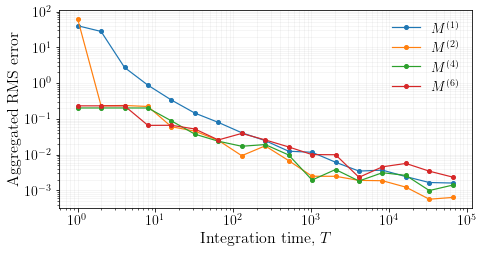

In [44]:
data_lengths_array = timelist=[1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536 ]  # 
data_lengths = [f"{data_lengths_array[i]}" for i in range(len(data_lengths_array))]

PlotAggregatedMomentErrors(N,    Theo_Coeff,    data_dict,    data_lengths,    adress_list,    moment_orders=(1, 2, 4, 6),    normalize=False,    eps=1e-12,    title=None, savepath= Examplename)

statistic1 =  0.010219500000000048 ---- p_value1 =  3.82063010738649e-91
statistic2 =  0.021115000000000023 ---- p_value2 =  0.0
statistic3 =  0.020067 ---- p_value3 =  0.0


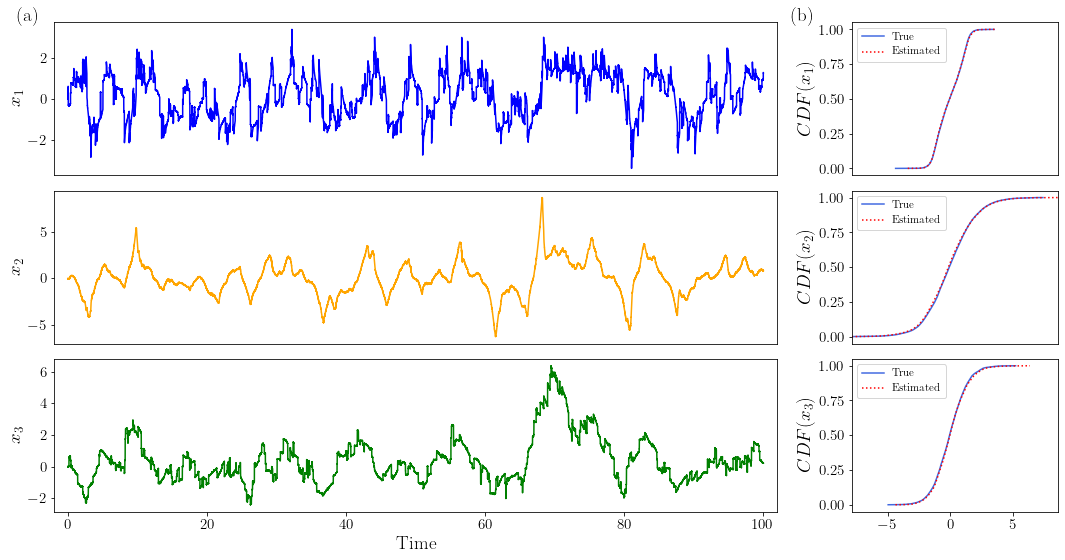

In [45]:
data_lengths_array = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536]   # [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
data_lengths = [f"{data_lengths_array[i]}" for i in range(len(data_lengths_array))]
plotC1(path1, exn, base_dir, data_lengths,data_lengths_array, M_values, Theo_Coeff, Examplename, dt, PT)

In [36]:
Lables = ['\\alpha',        '\phi_1',        '\phi_2',        '\phi_3',     '\\theta_{11}' ,        '\\theta_{12}',        '\\theta_{13}' ,        '\\theta_{22}' ,        '\\theta_{23}' ,        '\\theta_{33}' ,        '\gamma_{111}' ,        '\gamma_{112}' ,        '\gamma_{113}' ,        '\gamma_{122}' ,        '\gamma_{123}' ,        '\gamma_{133}' ,        '\gamma_{222}',        '\gamma_{223}' ,        '\gamma_{233}' ,        '\gamma_{333}'       ]
adress_list, adress_list2 = GetAdressList(N)
chosen_time= data_lengths[np.argmin(diff)]
All_Coeffs = AllCoeff_Table(N, Theo_Coeff, data_dict, chosen_time, adress_list)


In [37]:
Chosen_M=np.array([1,2,3,4,7])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([9,10,15,16,25])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")



$\alpha$&$0.000\pm0.002$&0&$0.000\pm0.000$&0&$-0.001\pm0.001$&0&\cellcolor{yellow!25}$2.41\pm0.001$&\cellcolor{yellow!25}2.41&\cellcolor{yellow!25}$0.04\pm0.000$&\cellcolor{yellow!25}0.04\\
$\phi_1$&$-0.008\pm0.002$&0&\cellcolor{yellow!25}$-1.003\pm0.000$&\cellcolor{yellow!25}-1&\cellcolor{yellow!25}$-0.497\pm0.001$&\cellcolor{yellow!25}-0.5&$0.002\pm0.002$&0&$0.000\pm0.000$&0\\
$\phi_2$&\cellcolor{yellow!25}$1.0\pm0.002$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$0.999\pm0.000$&\cellcolor{yellow!25}1&$-0.002\pm0.001$&0&$-0.002\pm0.001$&0&$0.000\pm0.000$&0\\
$\phi_3$&$-0.002\pm0.002$&0&\cellcolor{yellow!25}$0.999\pm0.000$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$-0.097\pm0.001$&\cellcolor{yellow!25}-0.1&$0.005\pm0.002$&0&$0.000\pm0.000$&0\\
$\gamma_{111}$&\cellcolor{yellow!25}$-0.995\pm0.001$&\cellcolor{yellow!25}-1&$0.002\pm0.000$&0&$0.000\pm0.001$&0&$-0.002\pm0.001$&0&$0.000\pm0.000$&0\\
$\gamma_{112}$&$0.001\pm0.001$&0&\cellcolor{yellow!25}$-0.998\pm0.000$&\cellcolor{yellow!25

In [ ]:

Chosen_M=np.array([1,2,3,4,5])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([6,7,8,9,10])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([11,12,13,14,15])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([16,17,18,19,20])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([21, 22, 23, 24, 25])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)

$\alpha$&$0.000\pm0.002$&0&$0.000\pm0.000$&0&$-0.001\pm0.001$&0&\cellcolor{yellow!25}$2.41\pm0.001$&\cellcolor{yellow!25}2.41&$0.000\pm0.000$&0\\
$\phi_1$&$-0.008\pm0.002$&0&\cellcolor{yellow!25}$-1.003\pm0.000$&\cellcolor{yellow!25}-1&\cellcolor{yellow!25}$-0.497\pm0.001$&\cellcolor{yellow!25}-0.5&$0.002\pm0.002$&0&$0.000\pm0.000$&0\\
$\phi_2$&\cellcolor{yellow!25}$1.0\pm0.002$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$0.999\pm0.000$&\cellcolor{yellow!25}1&$-0.002\pm0.001$&0&$-0.002\pm0.001$&0&$0.000\pm0.000$&0\\
$\phi_3$&$-0.002\pm0.002$&0&\cellcolor{yellow!25}$0.999\pm0.000$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$-0.097\pm0.001$&\cellcolor{yellow!25}-0.1&$0.005\pm0.002$&0&$0.000\pm0.000$&0\\
$\theta_{11}$&$0.001\pm0.001$&0&$0.000\pm0.000$&0&$-0.001\pm0.001$&0&$-0.001\pm0.001$&0&$0.000\pm0.000$&0\\
$\theta_{12}$&$-0.001\pm0.001$&0&$0.000\pm0.000$&0&$-0.001\pm0.001$&0&$0.002\pm0.001$&0&$0.000\pm0.000$&0\\
$\theta_{13}$&$0.002\pm0.001$&0&$0.000\pm0.000$&0&$0.000\pm0.001$&0&$-0

## C3

In [47]:
Examplename="Example C3"
exn="3D_#3_itoSRI2_5E4_dxfTrue"
base_dir = path1 + exn + "/"
ST = 1000  #simulate t
PT = 20   #plot t
N=3;dt=0.0005
nsteps=int(ST/dt)
x0 = np.array([0,0,0])
method="itoSRI2"

In [9]:
chosentimes = [16, 128, 1024, 65536]
dx_init = 0.01
dx_new = 0.1
PlotMoments(path1, exn, Examplename, chosentimes, dx_init, dx_new)

Maximum nbins found: 5261
Shape after padding: (4, 30, 3, 5261)
New nbins after rebinning: 526
Shape after rebinning: (4, 30, 3, 526)


68 Files read


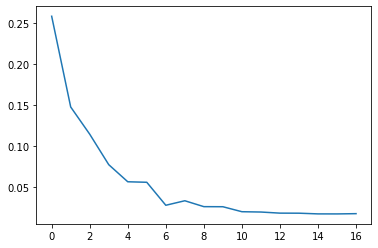

Lowest value: 0.017177666666666654, Index: 15,  T=32768


In [48]:
adress_list, adress_list2 = GetAdressList(N)
Theo_Coeff=np.loadtxt('Tables/Theo_Coeff_C3.csv', delimiter=',').T
data_dict = load_multiple_files(base_dir, exn, data_lengths, M_values)

diff = np.zeros(len(data_lengths))
for idx, chosen_time in enumerate(data_lengths):
    All_Coeffs = AllCoeff(N, Theo_Coeff, data_dict, chosen_time, adress_list)
    diff[idx] = np.mean(np.abs(Theo_Coeff- np.array([All_Coeffs[i,:] for i in range(0, len(All_Coeffs), 3)])))

plt.plot(diff)
plt.show()

print(f"Lowest value: {np.min(diff)}, Index: {np.argmin(diff)},  T={data_lengths[np.argmin(diff)]}")

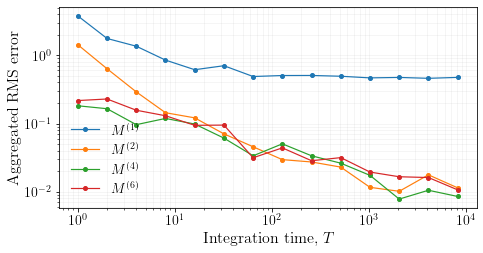

In [49]:
data_lengths_array = timelist=[1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192 ]  # , 16384, 32768, 65536
data_lengths = [f"{data_lengths_array[i]}" for i in range(len(data_lengths_array))]

PlotAggregatedMomentErrors(N,    Theo_Coeff,    data_dict,    data_lengths,    adress_list,    moment_orders=(1, 2, 4, 6),    normalize=False,    eps=1e-12,    title=None, savepath= Examplename)

statistic1 =  0.0060969999999999636 ---- p_value1 =  1.0246896535618212e-32
statistic2 =  0.018484500000000015 ---- p_value2 =  3.13732833573703e-297
statistic3 =  0.052985000000000004 ---- p_value3 =  0.0


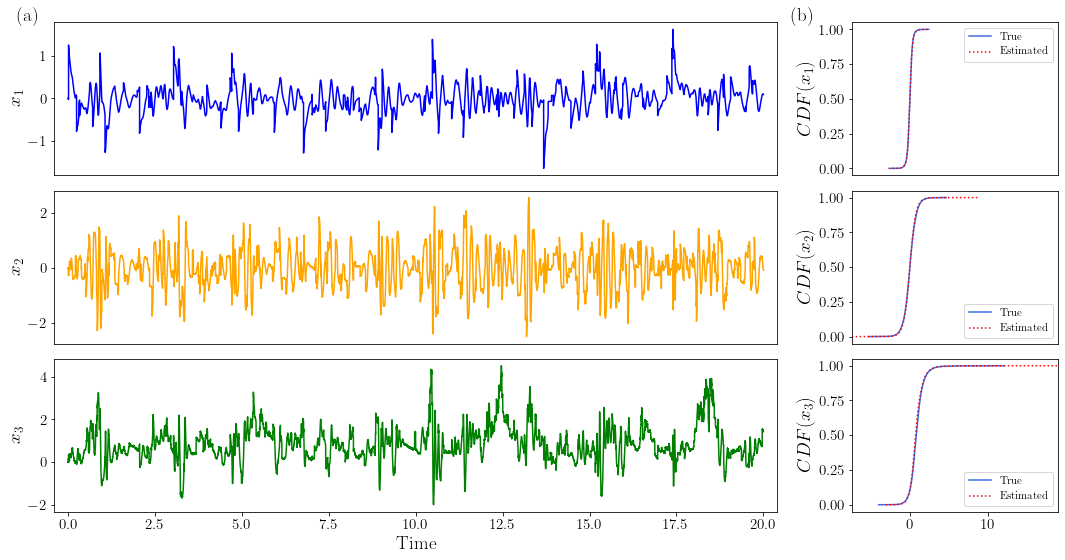

In [50]:
data_lengths_array = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536]   # [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
data_lengths = [f"{data_lengths_array[i]}" for i in range(len(data_lengths_array))]
plotC1(path1, exn, base_dir, data_lengths,data_lengths_array, M_values, Theo_Coeff, Examplename, dt, PT)

In [41]:
Lables = ['\\alpha',        '\phi_1',        '\phi_2',        '\phi_3',     '\\theta_{11}' ,        '\\theta_{12}',        '\\theta_{13}' ,        '\\theta_{22}' ,        '\\theta_{23}' ,        '\\theta_{33}' ,        '\gamma_{111}' ,        '\gamma_{112}' ,        '\gamma_{113}' ,        '\gamma_{122}' ,        '\gamma_{123}' ,        '\gamma_{133}' ,        '\gamma_{222}',        '\gamma_{223}' ,        '\gamma_{233}' ,        '\gamma_{333}'       ]
adress_list, adress_list2 = GetAdressList(N)
chosen_time= data_lengths[np.argmin(diff)]
All_Coeffs = AllCoeff_Table(N, Theo_Coeff, data_dict, chosen_time, adress_list)


In [42]:
Chosen_M=np.array([1,2,3,4,7])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([9,10,12,13,15])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([16,18,20,21,25])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")



$\alpha$&$-0.002\pm0.002$&0&$0.001\pm0.004$&0&$-0.005\pm0.005$&0&\cellcolor{yellow!25}$1.502\pm0.002$&\cellcolor{yellow!25}1.502&\cellcolor{yellow!25}$4.02\pm0.002$&\cellcolor{yellow!25}4.022\\
$\phi_1$&\cellcolor{yellow!25}$-9.909\pm0.006$&\cellcolor{yellow!25}-10&\cellcolor{yellow!25}$27.923\pm0.012$&\cellcolor{yellow!25}28&$0.009\pm0.012$&0&$-0.021\pm0.007$&0&$-0.007\pm0.009$&0\\
$\phi_2$&\cellcolor{yellow!25}$9.972\pm0.002$&\cellcolor{yellow!25}10&\cellcolor{yellow!25}$-0.922\pm0.005$&\cellcolor{yellow!25}-1&$0.004\pm0.006$&0&$-0.003\pm0.002$&0&$-0.009\pm0.004$&0\\
$\phi_3$&$-0.001\pm0.003$&0&$0.004\pm0.003$&0&\cellcolor{yellow!25}$-2.682\pm0.01$&\cellcolor{yellow!25}-2.667&$0.001\pm0.003$&0&$0.003\pm0.003$&0\\
$\theta_{12}$&$-0.001\pm0.006$&0&$-0.014\pm0.007$&0&\cellcolor{yellow!25}$99.668\pm0.009$&\cellcolor{yellow!25}100&$-0.008\pm0.006$&0&$-0.003\pm0.008$&0\\
$\theta_{13}$&$-0.242\pm0.006$&0&\cellcolor{yellow!25}$-99.673\pm0.011$&\cellcolor{yellow!25}-100&$0.047\pm0.022$&0&$0.0

In [ ]:

Chosen_M=np.array([1,2,3,4,5])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([6,7,8,9,10])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([11,12,13,14,15])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([16,17,18,19,20])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([21, 22, 23, 24, 25])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)


$\alpha$&$-0.002\pm0.002$&0&$0.001\pm0.004$&0&$-0.005\pm0.005$&0&\cellcolor{yellow!25}$1.502\pm0.002$&\cellcolor{yellow!25}1.502&$0.000\pm0.000$&0\\
$\phi_1$&\cellcolor{yellow!25}$-9.909\pm0.006$&\cellcolor{yellow!25}-10&\cellcolor{yellow!25}$27.923\pm0.012$&\cellcolor{yellow!25}28&$0.009\pm0.012$&0&$-0.021\pm0.007$&0&$-0.001\pm0.000$&0\\
$\phi_2$&\cellcolor{yellow!25}$9.972\pm0.002$&\cellcolor{yellow!25}10&\cellcolor{yellow!25}$-0.922\pm0.005$&\cellcolor{yellow!25}-1&$0.004\pm0.006$&0&$-0.003\pm0.002$&0&$0.000\pm0.000$&0\\
$\phi_3$&$-0.001\pm0.003$&0&$0.004\pm0.003$&0&\cellcolor{yellow!25}$-2.682\pm0.01$&\cellcolor{yellow!25}-2.667&$0.001\pm0.003$&0&$0.000\pm0.000$&0\\
$\theta_{11}$&$0.006\pm0.007$&0&$-0.003\pm0.01$&0&$0.671\pm0.012$&0&$-0.008\pm0.008$&0&$0.000\pm0.000$&0\\
$\theta_{12}$&$-0.001\pm0.006$&0&$-0.014\pm0.007$&0&\cellcolor{yellow!25}$99.668\pm0.009$&\cellcolor{yellow!25}100&$-0.008\pm0.006$&0&$0.000\pm0.000$&0\\
$\theta_{13}$&$-0.242\pm0.006$&0&\cellcolor{yellow!25}$-99.6

## D1

In [52]:
Examplename="Example D1"
exn="4D_#1_itoSRI2_5E4_dxfTrue"
base_dir = path1 + exn + "/"
ST = 1000  #simulate t
PT = 20   #plot t
N=4;dt=0.0005
nsteps=int(ST/dt)
x0 = np.array([0,0,0,0])
method="itoSRI2"

In [15]:
chosentimes = [16, 128, 1024, 4096]
dx_init = 0.01
dx_new = 0.1
PlotMoments(path1, exn, Examplename, chosentimes, dx_init, dx_new)

Maximum nbins found: 1401
Shape after padding: (4, 30, 4, 1401)
New nbins after rebinning: 140
Shape after rebinning: (4, 30, 4, 140)


In [53]:
timelist=[1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096] 
data_lengths = ["1", "2", "4", "8", "16", "32", "64", "128", "256", "512", "1024", "2048", "4096"] 
data_lengths_array = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

52 Files read


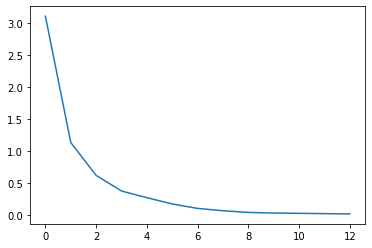

Lowest value: 0.023955844155844144, Index: 12,  T=4096


In [54]:
adress_list, adress_list2 = GetAdressList(N)
Theo_Coeff=np.loadtxt('Tables/Theo_Coeff_D1.csv', delimiter=',').T
data_dict = load_multiple_files(base_dir, exn, data_lengths, M_values)

diff = np.zeros(len(data_lengths))
for idx, chosen_time in enumerate(data_lengths):
    All_Coeffs = AllCoeff(N, Theo_Coeff, data_dict, chosen_time, adress_list)
    diff[idx] = np.mean(np.abs(Theo_Coeff- np.array([All_Coeffs[i,:] for i in range(0, len(All_Coeffs), 3)])))

plt.plot(diff)
plt.show()

print(f"Lowest value: {np.min(diff)}, Index: {np.argmin(diff)},  T={data_lengths[np.argmin(diff)]}")

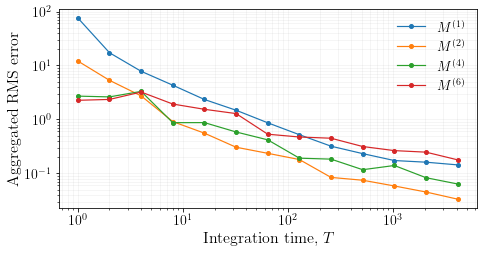

In [55]:
PlotAggregatedMomentErrors(N,    Theo_Coeff,    data_dict,    data_lengths,    adress_list,    moment_orders=(1, 2, 4, 6),    normalize=False,    eps=1e-12,    title=None, savepath= Examplename)

statistic1 =  0.013150999999999996 ---- p_value1 =  1.1750645083029721e-150
statistic2 =  0.012008999999999936 ---- p_value2 =  1.0692261280185714e-125
statistic3 =  0.01998600000000006 ---- p_value3 =  0.0
statistic4 =  0.006819999999999937 ---- p_value4 =  7.915702102715498e-41


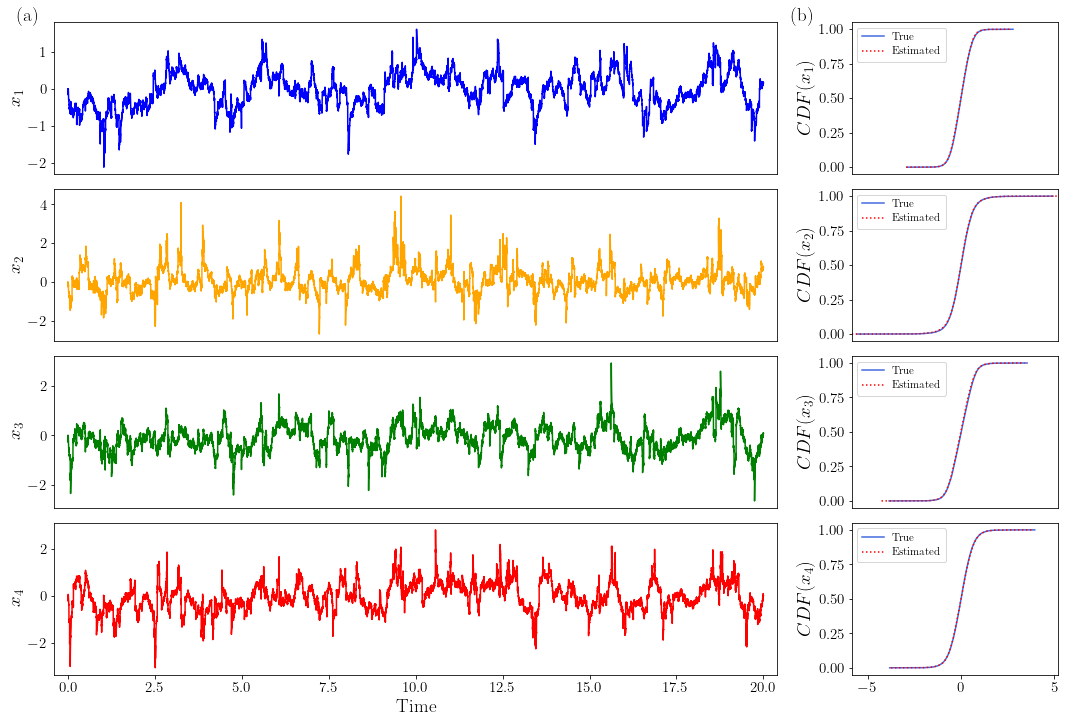

In [56]:
plotD1(path1, exn, base_dir, data_lengths,data_lengths_array, M_values, Theo_Coeff, Examplename, dt, PT)

In [50]:
Lables = GetLables(N)
adress_list, adress_list2 = GetAdressList(N)
chosen_time= data_lengths[np.argmin(diff)]
All_Coeffs = AllCoeff_Table(N, Theo_Coeff, data_dict, chosen_time, adress_list)


In [51]:
Chosen_M=np.array([1,2,3,4,5])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([6,7,8,9,10])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([11,12,13,14,15])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")

Chosen_M=np.array([17,19,21,22,24])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([25,27,32,35,37])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([40,41,42,43,44])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")

$\alpha$&$-0.003\pm0.007$&0&$0.009\pm0.012$&0&$-0.007\pm0.008$&0&$-0.01\pm0.011$&0&\cellcolor{yellow!25}$0.542\pm0.003$&\cellcolor{yellow!25}0.54\\
$\phi_1$&$-0.013\pm0.022$&0&\cellcolor{yellow!25}$1.037\pm0.042$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$0.988\pm0.034$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$1.058\pm0.028$&\cellcolor{yellow!25}1&$-0.003\pm0.014$&0\\
$\phi_2$&\cellcolor{yellow!25}$1.013\pm0.013$&\cellcolor{yellow!25}1&$-0.755\pm0.067$&0&\cellcolor{yellow!25}$1.008\pm0.019$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$0.954\pm0.03$&\cellcolor{yellow!25}1&$-0.002\pm0.007$&0\\
$\phi_3$&\cellcolor{yellow!25}$0.998\pm0.02$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$1.161\pm0.037$&\cellcolor{yellow!25}1&$-0.153\pm0.032$&0&\cellcolor{yellow!25}$1.022\pm0.023$&\cellcolor{yellow!25}1&$0.018\pm0.009$&0\\
$\phi_4$&\cellcolor{yellow!25}$0.995\pm0.014$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$0.936\pm0.039$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$1.008\pm0.021$&\c

In [ ]:

Chosen_M=np.array([1,2,3,4,5])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([6,7,8,9,10])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([11,12,13,14,15])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([16,17,18,19,20])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([21, 22, 23, 24, 25])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([26,27,28,29,30])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([31,32,33,34,35])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([36,37,38,39,40])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([41,42,43,44])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)

$\alpha$&$-0.003\pm0.007$&0&$0.009\pm0.012$&0&$-0.007\pm0.008$&0&$-0.01\pm0.011$&0&\cellcolor{yellow!25}$0.542\pm0.003$&\cellcolor{yellow!25}0.54\\
$\phi_1$&$-0.013\pm0.022$&0&\cellcolor{yellow!25}$1.037\pm0.042$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$0.988\pm0.034$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$1.058\pm0.028$&\cellcolor{yellow!25}1&$-0.003\pm0.014$&0\\
$\phi_2$&\cellcolor{yellow!25}$1.013\pm0.013$&\cellcolor{yellow!25}1&$-0.755\pm0.067$&0&\cellcolor{yellow!25}$1.008\pm0.019$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$0.954\pm0.03$&\cellcolor{yellow!25}1&$-0.002\pm0.007$&0\\
$\phi_3$&\cellcolor{yellow!25}$0.998\pm0.02$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$1.161\pm0.037$&\cellcolor{yellow!25}1&$-0.153\pm0.032$&0&\cellcolor{yellow!25}$1.022\pm0.023$&\cellcolor{yellow!25}1&$0.018\pm0.009$&0\\
$\phi_4$&\cellcolor{yellow!25}$0.995\pm0.014$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$0.936\pm0.039$&\cellcolor{yellow!25}1&\cellcolor{yellow!25}$1.008\pm0.021$&\c

## D2

In [58]:
Examplename="Example D2"
exn="4D_#2_itoSRI2_5E4_dxfTrue"
base_dir = path1 + exn + "/"
ST = 1000  #simulate t
PT = 100   #plot t
N=4;dt=0.0005
nsteps=int(ST/dt)
x0 = np.array([0,0,0,0])
method="itoSRI2"

In [28]:
chosentimes = [16, 128, 1024, 4096]
dx_init = 0.01
dx_new = 0.1
PlotMoments(path1, exn, Examplename, chosentimes, dx_init, dx_new)

Maximum nbins found: 2461
Shape after padding: (4, 30, 4, 2461)
New nbins after rebinning: 246
Shape after rebinning: (4, 30, 4, 246)


In [59]:
timelist=[1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096] 
data_lengths = ["1", "2", "4", "8", "16", "32", "64", "128", "256", "512", "1024", "2048", "4096"] 
data_lengths_array = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

52 Files read


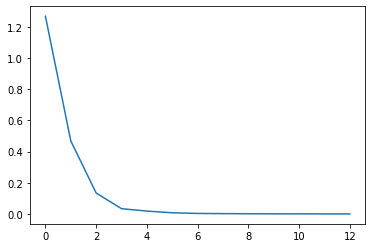

Lowest value: 0.0005330844155844169, Index: 12,  T=4096


In [60]:
adress_list, adress_list2 = GetAdressList(N)
Theo_Coeff=np.loadtxt('Tables/Theo_Coeff_D2.csv', delimiter=',').T
data_dict = load_multiple_files(base_dir, exn, data_lengths, M_values)

diff = np.zeros(len(data_lengths))
for idx, chosen_time in enumerate(data_lengths):
    All_Coeffs = AllCoeff(N, Theo_Coeff, data_dict, chosen_time, adress_list)
    diff[idx] = np.mean(np.abs(Theo_Coeff- np.array([All_Coeffs[i,:] for i in range(0, len(All_Coeffs), 3)])))

plt.plot(diff)
plt.show()

print(f"Lowest value: {np.min(diff)}, Index: {np.argmin(diff)},  T={data_lengths[np.argmin(diff)]}")

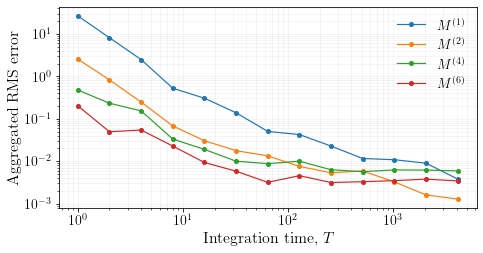

In [61]:
PlotAggregatedMomentErrors(N,    Theo_Coeff,    data_dict,    data_lengths,    adress_list,    moment_orders=(1, 2, 4, 6),    normalize=False,    eps=1e-12,    title=None, savepath= Examplename)

statistic1 =  0.017816000000000054 ---- p_value1 =  3.7825503067243516e-276
statistic2 =  0.0298775 ---- p_value2 =  0.0
statistic3 =  0.01305400000000001 ---- p_value3 =  1.8971909782079142e-148
statistic4 =  0.025774500000000006 ---- p_value4 =  0.0


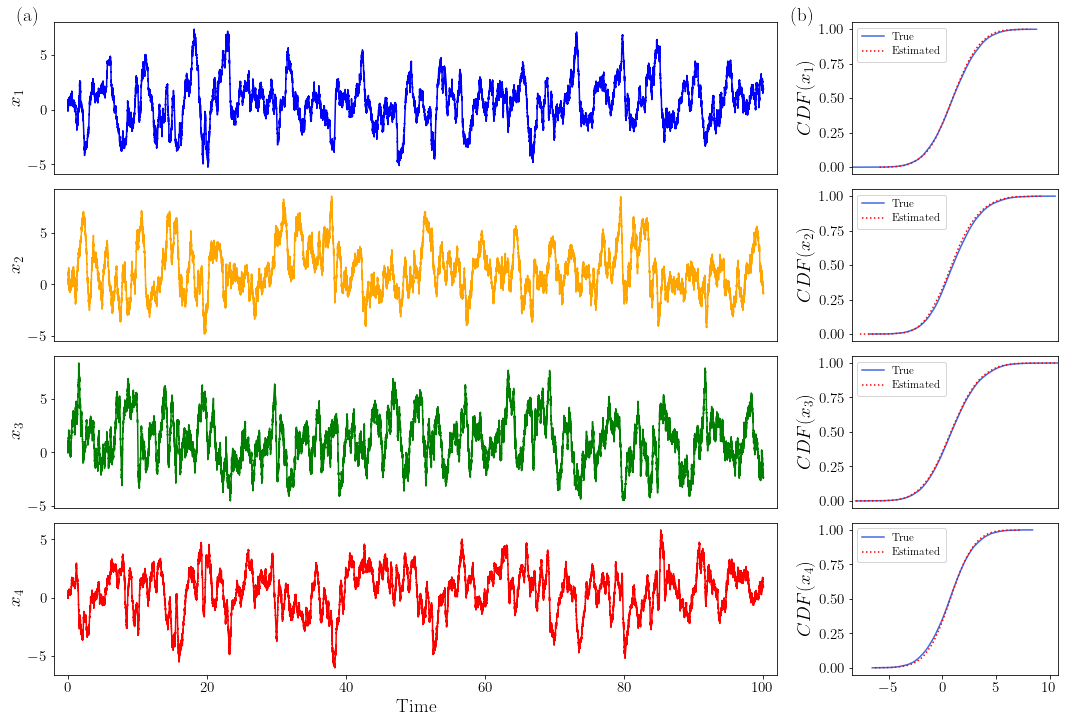

In [62]:
plotD1(path1, exn, base_dir, data_lengths,data_lengths_array, M_values, Theo_Coeff, Examplename, dt, PT)

In [ ]:
Lables = GetLables(N)
adress_list, adress_list2 = GetAdressList(N)
chosen_time= data_lengths[np.argmin(diff)]
All_Coeffs = AllCoeff_Table(N, Theo_Coeff, data_dict, chosen_time, adress_list)


In [57]:
Chosen_M=np.array([1,2,3,4,5])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([6,7,8,9,10])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([11,12,13,14,15])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([16,17,18,19,20])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([21, 22, 23, 24, 25])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([27,28,32,34,35])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([36,38,41,43,44])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")

$\alpha$&\cellcolor{yellow!25}$2.497\pm0.012$&\cellcolor{yellow!25}2.5&\cellcolor{yellow!25}$2.502\pm0.016$&\cellcolor{yellow!25}2.5&\cellcolor{yellow!25}$2.473\pm0.019$&\cellcolor{yellow!25}2.5&\cellcolor{yellow!25}$2.507\pm0.013$&\cellcolor{yellow!25}2.5&\cellcolor{yellow!25}$4.793\pm0.007$&\cellcolor{yellow!25}4.79\\
$\phi_1$&\cellcolor{yellow!25}$-0.996\pm0.007$&\cellcolor{yellow!25}-1&$-0.013\pm0.008$&0&$0.000\pm0.01$&0&$0.000\pm0.006$&0&$0.000\pm0.004$&0\\
$\phi_2$&$-0.017\pm0.006$&0&\cellcolor{yellow!25}$-1.001\pm0.006$&\cellcolor{yellow!25}-1&$0.000\pm0.006$&0&$0.000\pm0.004$&0&$0.000\pm0.003$&0\\
$\phi_3$&$0.000\pm0.007$&0&$0.000\pm0.008$&0&\cellcolor{yellow!25}$-0.999\pm0.007$&\cellcolor{yellow!25}-1&$0.000\pm0.005$&0&$0.000\pm0.003$&0\\
$\phi_4$&$-0.008\pm0.007$&0&$0.000\pm0.007$&0&$0.016\pm0.01$&0&\cellcolor{yellow!25}$-1.004\pm0.005$&\cellcolor{yellow!25}-1&$0.000\pm0.004$&0\\
$\theta_{12}$&$0.000\pm0.002$&0&$-0.003\pm0.003$&0&\cellcolor{yellow!25}$-1.0\pm0.003$&\cellcolor

In [ ]:

Chosen_M=np.array([1,2,3,4,5])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([6,7,8,9,10])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([11,12,13,14,15])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([16,17,18,19,20])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([21, 22, 23, 24, 25])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([26,27,28,29,30])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([31,32,33,34,35])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([36,37,38,39,40])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([41,42,43,44])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)

$\alpha$&\cellcolor{yellow!25}$2.497\pm0.012$&\cellcolor{yellow!25}2.5&\cellcolor{yellow!25}$2.502\pm0.016$&\cellcolor{yellow!25}2.5&\cellcolor{yellow!25}$2.473\pm0.019$&\cellcolor{yellow!25}2.5&\cellcolor{yellow!25}$2.507\pm0.013$&\cellcolor{yellow!25}2.5&\cellcolor{yellow!25}$4.793\pm0.007$&\cellcolor{yellow!25}4.79\\
$\phi_1$&\cellcolor{yellow!25}$-0.996\pm0.007$&\cellcolor{yellow!25}-1&$-0.013\pm0.008$&0&$0.009\pm0.01$&0&$-0.001\pm0.006$&0&$0.002\pm0.004$&0\\
$\phi_2$&$-0.017\pm0.006$&0&\cellcolor{yellow!25}$-1.001\pm0.006$&\cellcolor{yellow!25}-1&$-0.001\pm0.006$&0&$-0.002\pm0.004$&0&$-0.001\pm0.003$&0\\
$\phi_3$&$0.004\pm0.007$&0&$-0.005\pm0.008$&0&\cellcolor{yellow!25}$-0.999\pm0.007$&\cellcolor{yellow!25}-1&$0.001\pm0.005$&0&$-0.001\pm0.003$&0\\
$\phi_4$&$-0.008\pm0.007$&0&$0.004\pm0.007$&0&$0.016\pm0.01$&0&\cellcolor{yellow!25}$-1.004\pm0.005$&\cellcolor{yellow!25}-1&$0.002\pm0.004$&0\\
$\theta_{11}$&$0.001\pm0.001$&0&$0.000\pm0.002$&0&$-0.005\pm0.002$&0&$0.002\pm0.002$&0&$0.0

## D3

In [64]:
Examplename="Example D3"
exn="4D_#3_itoSRI2_5E4_dxfTrue"
base_dir = path1 + exn + "/"
ST = 1000  #simulate t
PT = 100   #plot t
N=4;dt=0.0005
nsteps=int(ST/dt)
x0 = np.array([0,0,0,0])
method="itoSRI2"

In [3]:
chosentimes = [16, 128, 1024, 4096]
dx_init = 0.1
dx_new = 0.5
PlotMoments(path1, exn, Examplename, chosentimes, dx_init, dx_new)

Maximum nbins found: 333
Shape after padding: (4, 30, 4, 333)
New nbins after rebinning: 66
Shape after rebinning: (4, 30, 4, 66)


In [65]:
timelist=[1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192] 
data_lengths = ["1", "2", "4", "8", "16", "32", "64", "128", "256", "512", "1024", "2048", "4096", "8192"] 
data_lengths_array = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]

56 Files read


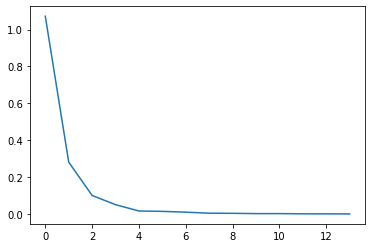

Lowest value: 0.0004889610389610365, Index: 13,  T=8192


In [66]:
adress_list, adress_list2 = GetAdressList(N)
Theo_Coeff=np.loadtxt('Tables/Theo_Coeff_D3.csv', delimiter=',').T
data_dict = load_multiple_files(base_dir, exn, data_lengths, M_values)

diff = np.zeros(len(data_lengths))
max_diff = np.zeros(len(data_lengths))
for idx, chosen_time in enumerate(data_lengths):
    All_Coeffs = AllCoeff(N, Theo_Coeff, data_dict, chosen_time, adress_list)
    diff[idx] = np.mean(np.abs(Theo_Coeff- np.array([All_Coeffs[i,:] for i in range(0, len(All_Coeffs), 3)])))
    max_diff[idx] = np.max(np.abs(Theo_Coeff- np.array([All_Coeffs[i,:] for i in range(0, len(All_Coeffs), 3)])))

plt.plot(diff)
# plt.plot(max_diff)
# plt.yscale('log')
plt.show()

print(f"Lowest value: {np.min(diff)}, Index: {np.argmin(diff)},  T={data_lengths[np.argmin(diff)]}")

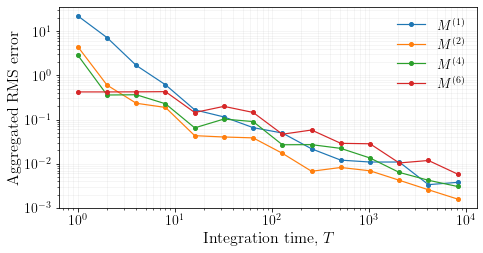

In [67]:
PlotAggregatedMomentErrors(N,    Theo_Coeff,    data_dict,    data_lengths,    adress_list,    moment_orders=(1, 2, 4, 6),    normalize=False,    eps=1e-12,    title=None, savepath= Examplename)

statistic1 =  0.011617000000000002 ---- p_value1 =  1.1858323035318822e-117
statistic2 =  0.01474299999999995 ---- p_value2 =  3.1233289344443624e-189
statistic3 =  0.021901999999999977 ---- p_value3 =  0.0
statistic4 =  0.017747000000000013 ---- p_value4 =  5.122573940419535e-274


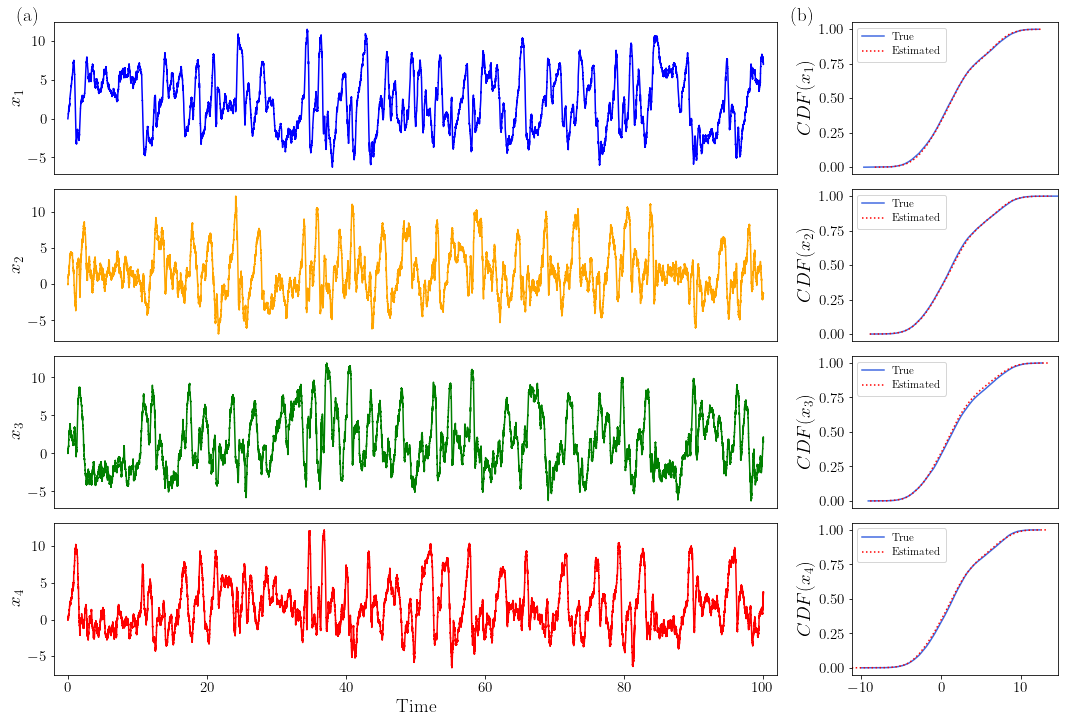

In [68]:
plotD1(path1, exn, base_dir, data_lengths,data_lengths_array, M_values, Theo_Coeff, Examplename, dt, PT)

In [62]:
Lables = GetLables(N)
adress_list, adress_list2 = GetAdressList(N)
chosen_time= data_lengths[np.argmin(diff)]
All_Coeffs = AllCoeff_Table(N, Theo_Coeff, data_dict, chosen_time, adress_list)


In [63]:
Chosen_M=np.array([1,2,3,4,5])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([6,7,8,9,10])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([11,12,13,14,15])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([16,17,18,19,20])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([21, 22, 23, 24, 25])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([27,28,32,34,35])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([36,38,41,43,44])
PrintRowsskip(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")

$\alpha$&\cellcolor{yellow!25}$7.997\pm0.012$&\cellcolor{yellow!25}8&\cellcolor{yellow!25}$8.005\pm0.021$&\cellcolor{yellow!25}8&\cellcolor{yellow!25}$8.033\pm0.02$&\cellcolor{yellow!25}8&\cellcolor{yellow!25}$8.007\pm0.019$&\cellcolor{yellow!25}8&\cellcolor{yellow!25}$2.197\pm0.005$&\cellcolor{yellow!25}2.2\\
$\phi_1$&\cellcolor{yellow!25}$-0.991\pm0.003$&\cellcolor{yellow!25}-1&$-0.008\pm0.006$&0&$-0.008\pm0.004$&0&$0.003\pm0.004$&0&$0.000\pm0.002$&0\\
$\phi_2$&$-0.001\pm0.002$&0&\cellcolor{yellow!25}$-1.002\pm0.004$&\cellcolor{yellow!25}-1&$0.001\pm0.004$&0&$-0.002\pm0.004$&0&$0.001\pm0.002$&0\\
$\phi_3$&$0.007\pm0.003$&0&$0.002\pm0.005$&0&\cellcolor{yellow!25}$-1.007\pm0.005$&\cellcolor{yellow!25}-1&$0.002\pm0.005$&0&$0.003\pm0.002$&0\\
$\phi_4$&$-0.004\pm0.002$&0&$-0.02\pm0.005$&0&$0.001\pm0.005$&0&\cellcolor{yellow!25}$-0.994\pm0.005$&\cellcolor{yellow!25}-1&$0.000\pm0.001$&0\\
$\theta_{12}$&$0.000\pm0.001$&0&$0.001\pm0.001$&0&\cellcolor{yellow!25}$-1.001\pm0.001$&\cellcolor{yell

In [ ]:

Chosen_M=np.array([1,2,3,4,5])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([6,7,8,9,10])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([11,12,13,14,15])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([16,17,18,19,20])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([21, 22, 23, 24, 25])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([26,27,28,29,30])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([31,32,33,34,35])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([36,37,38,39,40])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)
print("______________________________________________________________________________")
Chosen_M=np.array([41,42,43,44])
PrintRows(Theo_Coeff, Lables, Chosen_M, All_Coeffs)

$\alpha$&\cellcolor{yellow!25}$7.997\pm0.012$&\cellcolor{yellow!25}8&\cellcolor{yellow!25}$8.005\pm0.021$&\cellcolor{yellow!25}8&\cellcolor{yellow!25}$8.033\pm0.02$&\cellcolor{yellow!25}8&\cellcolor{yellow!25}$8.007\pm0.019$&\cellcolor{yellow!25}8&\cellcolor{yellow!25}$2.197\pm0.005$&\cellcolor{yellow!25}2.2\\
$\phi_1$&\cellcolor{yellow!25}$-0.991\pm0.003$&\cellcolor{yellow!25}-1&$-0.008\pm0.006$&0&$-0.008\pm0.004$&0&$0.003\pm0.004$&0&$0.000\pm0.002$&0\\
$\phi_2$&$-0.001\pm0.002$&0&\cellcolor{yellow!25}$-1.002\pm0.004$&\cellcolor{yellow!25}-1&$0.001\pm0.004$&0&$-0.002\pm0.004$&0&$0.001\pm0.002$&0\\
$\phi_3$&$0.007\pm0.003$&0&$0.002\pm0.005$&0&\cellcolor{yellow!25}$-1.007\pm0.005$&\cellcolor{yellow!25}-1&$0.002\pm0.005$&0&$0.003\pm0.002$&0\\
$\phi_4$&$-0.004\pm0.002$&0&$-0.02\pm0.005$&0&$0.001\pm0.005$&0&\cellcolor{yellow!25}$-0.994\pm0.005$&\cellcolor{yellow!25}-1&$0.000\pm0.001$&0\\
$\theta_{11}$&$0.000\pm0.001$&0&$0.002\pm0.001$&0&$-0.001\pm0.001$&0&$0.000\pm0.001$&0&$0.000\pm0.000$&